# Grading the Entertainment Value of an NFL Game

## DSCI-521 | Data Analysis and Interpretation | Term Project, Phase 2

**Summer 2026 | Group 3** - Sravya Guntaka, Trevor McCaffrey, Ian Nemetz, Ty Pacchione

---

Every NFL Sunday offers a dozen games and a typical viewer can watch one closely. Broadcasters decide months in advance which game gets the national window, and the league's flexible-scheduling rules let it move a game into primetime with twelve days' notice. Both decisions are bets on which game will be *worth watching* - a bet placed before anyone knows what happens.

This report focuses on an area not generally explored in related research; whether that bet can be made from data. This report builds a per-game measure of excitement from win-probability movement, checks that it measures what the team's claim, uses it to explain what actually separates a thriller from a dud, and then tests the guiding question: **can a game's entertainment value be predicted before kickoff?**

Bottom line up front: the short answer established in Section 6 is *barely*. This negative result is an interesting finding in this report.

## 1. Problem Statement

The Project Scoping in Phase 1 presented four questions and this phase answers them under a single thesis: **an NFL game's
entertainment value can be measured and explained after the fact, but is close to unpredictable before kickoff.**

| # | Phase 1 question | Where it is answered |
|---|---|---|
| 1 | Is the entertainment value of every NFL game "grade-able"? | §4.1-4.2, validated in §5.1 |
| 2 | What advanced metrics correlate with winning? | §5.2 |
| 3 | How do location and rest affect outcomes? | §4.4, §5.2 |
| 4 | Can we build "momentum" charts? | §4.3, generalized into archetypes in §6.2 |

### Why anyone should care

- **Broadcasters and the league office.** The NFL's flex-scheduling rules exist to move good
  games into primetime. If pre-game excitement is predictable, flex decisions can be data-driven; if it is not, the league is buying lottery tickets and should optimize for something it *can* control.
- **Fans.** With ten games kicking off in the same window, "which one do I put on?" is a real decision made weekly by millions of people.
- **Analysts and researchers.** A validated game-level excitement measure is a building block for studying competitive balance, rule changes, and parity over time. The results can also influence legalized sports betting outcomes for oddsmakers and bettors alike. 

### What counts as an answer

We commit in advance to the standards a result must clear:

1. The excitement measure must agree with independent notions of a good game (§5.1), and failure modes must be named rather than hidden.
2. Every model is scored on **seasons it never saw during training**. A model that cannot beat a trivial baseline out of sample has not found anything.
3. A null result is reported as such.

## 2. Methodology

### 2.1 Data source, and why it changed since Phase 1

Phase 1 used the [nflscrapR](https://github.com/ryurko/nflscrapR-data) CSVs. That archive stops after the 2019 season and carries no pre-game context for betting lines, rest days, or weather. Since the central question of this phase is about making a *pre-game* prediction, that dataset was not anticipated to answer it.

The team moved to **[nflverse](https://nflreadr.nflverse.com/)** via the `nflreadpy` package, the actively maintained successor to nflscrapR (same lineage of expected-points and win-probability models). It gives us **2016-2025, regular season and playoffs**, and its schedule table supplies the closing spread, over/under, rest days, roof, surface, temperature, wind, and kickoff times which this work depends on.

### 2.2 The Game Excitement Index (GEI)

Win probability (WP) is the model-estimated chance the home team wins, updated after every play. Win Probability Added (WPA) is one play's change in that number. Following ESPN/NFL statistical forumulations from Brian Burke, a game's excitement is defined as the total distance the win probability travels:

$$\text{GEI} = \sum_{p \,\in\, \text{plays}} \left| \text{WPA}_p \right|$$

A blowout's WP line is nearly flat, so its GEI is small. A game with repeated swings racks up distance. Section 5.1 tests whether this tracks what people mean by a good game, and documents how it is overstated for games that go into **overtime**.

### 2.3 Validation protocol

Games in the dataset are ordered in time, so a random train/test split would let a model learn from the future to predict the past or worse, learn season-specific quirks (a rule change, a scoring environment) that it then gets tested on. Every model here is therefore split **by season**:

- **Headline split:** train on 2016-2024, test on the held-out **2025** season.
- **Walking validation:** for each season *s* from 2020-2025, train on every season before *s* and test on *s*. One 285-game season is small enough that a single split is noisy, so six seasons are used as their cumulative data gives a more reliable mean and a spread. Section 6.1 shows a case where this distinction changes the conclusion.

### 2.4 Models

| Question | Model | Baseline to beat |
|---|---|---|
| What wins games? (§5.2) | Logistic regression on standardized team-game features | 50% / AUC 0.5 |
| How exciting will this game be? (§6.1) | RidgeCV, HistGradientBoosting | Predict the training mean |
| Will this game be a thriller? (§6.1) | Logistic regression, HistGradientBoosting | Predict the base rate (AUC 0.5) |
| What kinds of games are there? (§6.2) | PCA + KMeans on WP-curve shape | unsupervised |

## 3. Data and Environment

### 3.1 Setup

All analysis code is in this notebook. The project's data layer package is imported from `src/`, which wraps `nflreadpy` in an on-disk parquet cache to avoid re-fetching each season of play-by-play (a ~20 MB download each) every kernel restart.

To reproduce: create the environment from `requirements.txt`, then run this notebook top to bottom. The first run downloads and caches the data (~1 minute); later runs read the cache.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

sys.path.insert(0, str(Path.cwd() / "src"))
from data import load_pbp_seasons, load_schedules_seasons   # noqa: E402
from plots import show_wp_graph, show_excitement_chart      # noqa: E402

SEASONS = list(range(2016, 2026))
TEST_SEASON = 2025
TRAIN_SEASONS = [s for s in SEASONS if s < TEST_SEASON]
RANDOM_STATE = 0

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=FutureWarning)

print("python     ", sys.version.split()[0])
for m in (np, pd, mpl):
    print(f"{m.__name__:<11} {m.__version__}")
import sklearn; print(f"{'sklearn':<11} {sklearn.__version__}")
print(f"\nseasons    {SEASONS[0]}-{SEASONS[-1]}  |  held-out test season: {TEST_SEASON}")

python      3.12.3
numpy       2.5.1
pandas      3.0.3
matplotlib  3.11.0
sklearn     1.9.0

seasons    2016-2025  |  held-out test season: 2025


#### Visual conventions

Every figure in this report follows a consistent set of rules, so that color always means the same thing:

- **Magnitude** (how exciting, how much) uses a single blue ramp where light = low. Phase 1's excitement grid used a rainbow which did not provide the same clarity without referring to the legend.
- **Polarity** (helps vs. hurts) uses a blue to red gradient with a neutral grey midpoint.
- **Identity** (this series vs. that one) uses blue and orange to remain distinguishable.

In [3]:
# setup report color palette
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RED = "#d03b3b"
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
BLUE_RAMP = LinearSegmentedColormap.from_list(
    "gei_blues", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
# Positive = blue, negative = red, neutral grey midpoint
DIVERGING = LinearSegmentedColormap.from_list(
    "red_blue", ["#a32020", "#e34948", "#f2a3a3", "#f0efec", "#9ec5f4", "#3987e5", "#184f95"])

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "font.size": 10, "figure.dpi": 110, "savefig.bbox": "tight",
})

def tidy(ax, grid_axis="y"):
    """Recessive grid behind the data, no chart junk."""
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis, linewidth=0.8, color=GRID)
    return ax

In [5]:
# load schedule and play-by-play data
sched = load_schedules_seasons(SEASONS)
pbp = load_pbp_seasons(SEASONS)
print(f"\nschedules {sched.shape}   play-by-play {pbp.shape}")

schedules 2016 ... 267 games
schedules 2017 ... 267 games
schedules 2018 ... 267 games
schedules 2019 ... 267 games
schedules 2020 ... 269 games
schedules 2021 ... 285 games
schedules 2022 ... 284 games
schedules 2023 ... 285 games
schedules 2024 ... 285 games
schedules 2025 ... 285 games
pbp 2016 ... 47,651 plays
pbp 2017 ... 47,245 plays
pbp 2018 ... 47,109 plays
pbp 2019 ... 47,260 plays
pbp 2020 ... 47,705 plays
pbp 2021 ... 49,922 plays
pbp 2022 ... 49,434 plays
pbp 2023 ... 49,665 plays
pbp 2024 ... 49,492 plays
pbp 2025 ... 48,771 plays

schedules (2761, 27)   play-by-play (484254, 49)


### 3.2 Coverage check

Before any analysis, it is important to confirm every scheduled game actually has play-by-play attached so that a join failure does not silently drop games from every table downstream.

In [6]:
cov = (sched.groupby("season")
       .agg(games=("game_id", "size"),
            regular=("game_type", lambda s: (s == "REG").sum()),
            playoff=("game_type", lambda s: (s != "REG").sum()))
       .assign(plays=pbp.groupby("season").size(),
               plays_per_game=lambda d: (d["plays"] / d["games"]).round(1)))
print(cov.to_string())
print(f"\nTOTAL  {cov.games.sum():,} games   {cov.plays.sum():,} plays")

missing = set(sched.game_id) - set(pbp.game_id)
print(f"scheduled games with no play-by-play: {len(missing)}")
assert not missing, f"missing play-by-play for {sorted(missing)[:5]}"
print("unscored (unplayed) games:", int(sched.home_score.isna().sum()))

        games  regular  playoff  plays  plays_per_game
season                                                
2016      267      256       11  47651           178.5
2017      267      256       11  47245           176.9
2018      267      256       11  47109           176.4
2019      267      256       11  47260           177.0
2020      269      256       13  47705           177.3
2021      285      272       13  49922           175.2
2022      284      271       13  49434           174.1
2023      285      272       13  49665           174.3
2024      285      272       13  49492           173.7
2025      285      272       13  48771           171.1

TOTAL  2,761 games   484,254 plays
scheduled games with no play-by-play: 0
unscored (unplayed) games: 0


The dataset contains 2,761 games and 484,254 plays, with complete coverage. Every scheduled game has play-by-play and a final score.

### 3.3 Missing data and cleaning

`nflreadpy` returns 372 play columns, but `src/data.py` narrows this down to the ~49 the project uses.

In [12]:
def missing_report(df, cols, label):
    rep = pd.DataFrame({
        "null_frac": df[cols].isna().mean().round(4),
        "dtype": df[cols].dtypes.astype(str),
    }).sort_values("null_frac", ascending=False)
    print(f"{label}:")
    print(rep[rep.null_frac > 0].to_string() or "  (no missing values)")
    return rep

_ = missing_report(pbp, ["wpa", "home_wp", "epa", "success", "play_type", "down",
                         "third_down_converted", "yards_gained", "score_differential"],
                   "play-by-play (analysis columns)")
print()
_ = missing_report(sched, ["temp", "wind", "spread_line", "total_line", "home_rest",
                           "away_rest", "roof", "div_game", "gametime", "result"],
                   "schedules (analysis columns)")

# `third_down_converted` is 0-filled off third down rather than null, so a naive mean divides by every play in the game.
print("\nthird_down_converted cleanup example")
print(pbp.groupby(pbp["down"].fillna(-1))["third_down_converted"]
      .agg(["mean", "count"]).round(3).to_string())
print(f"\n  3rd down converted mean over all plays : {pbp.third_down_converted.mean():.3f}   <- wrong, obviously too low")
print(f"  3rd down converted mean where down == 3: {pbp.loc[pbp.down == 3, 'third_down_converted'].mean():.3f}"
      "   <- correct, makes more sense")

play-by-play (analysis columns):
                      null_frac    dtype
down                     0.1592  float64
score_differential       0.0535  float64
yards_gained             0.0304  float64
third_down_converted     0.0304  float64
play_type                0.0293      str
wpa                      0.0148  float64
epa                      0.0115  float64
success                  0.0115  float64

schedules (analysis columns):
      null_frac    dtype
temp     0.3499  float64
wind     0.3499  float64

third_down_converted cleanup example
       mean   count
down               
-1.0  0.000   62949
 1.0  0.000  164050
 2.0  0.000  122964
 3.0  0.362   77941
 4.0  0.000   41636

  3rd down converted mean over all plays : 0.060   <- wrong, obviously too low
  3rd down converted mean where down == 3: 0.362   <- correct, makes more sense


**How each null is handled, and why:**

| Column | Null | Cause | Treatment |
|---|---|---|---|
| `temp`, `wind` | ~35% | Absent values for indoor games | Filled with 70 °F / 0 mph in §6.1 since using the outdoor median would be unfair. A dome is not an average weather stadium, it is a controlled one. |
| `wpa` | 1.5% | Timeouts, quarter ends, and other non-plays carry no WP change | Dropped from the sum as a null WPA contributes zero excitement by definition |
| `down` | 15.9% | Undefined on kickoffs, extra points, and other non-scrimmage plays | Filtered out before any down-based aggregation |
| `third_down_converted` | 3.0% | Zero-filled, not null, on plays that are not third downs | We filter to `down == 3` before averaging. Averaging the raw column would understate every team's conversion rate. |
| `success`, `epa` | 1.1% | Undefined on non-scrimmage plays | Aggregated over run/pass plays only |
| `score_differential` | 5.4% | Null when no team has possession (between periods) | Not used directly. Lead changes come from the home/away totals instead in §4.1 |

A player injury-related column would likely be informative but is not available in the dataset. Losing a star quarterback in the first quarter changes a game in a way none of the other dataset features can see. This is recorded as a limitation in §8.

### 3.4 Ordering plays within a game

Several measures below depend on reading a game's plays *in order*: lead changes, fourth-quarter volatility, and the momentum charts. The obvious sort key is `game_seconds_remaining`, counting down 3600 to 0, but it is wrong.

In overtime, `game_seconds_remaining` **restarts at 600**. Sorting a game by that column descending therefore interleaves the overtime plays into the middle of the second quarter. Since overtime games are the games with the most dramatic endings, this corrupts the games the analysis cares most about.

The nflverse file order is already correct, and equals sorting by quarter ascending then `quarter_seconds_remaining` descending, so the analysis uses that.

In [15]:
ORDER_COLS = ["game_id", "qtr", "quarter_seconds_remaining"]
ORDER_ASC = [True, True, False]
pbp = pbp.sort_values(ORDER_COLS, ascending=ORDER_ASC, kind="stable").reset_index(drop=True)
print("\nplay-by-play sorted into true game order")


play-by-play sorted into true game order


## 4. Data Exploration

### 4.1 Computing the Game Excitement Index

Five *independent* metrics that describe a game are computed alongside GEI, which §5.1 uses verify what GEI is measuring:

| Measure | Definition |
|---|---|
| `gei` | Σ&#124;WPA&#124; over all plays, the headline rollup measure |
| `gei_per_play` | GEI divided by total number of plays |
| `comeback` | the largest win-probability hole the eventual winner climbed out of |
| `lead_changes` | times the scoreboard lead actually changed hands |
| `big_swings` | plays that moved win probability by more than 10 points |
| `late_tension` | how close to a coin flip the game was in the last 5 minutes |

In [ ]:
def game_measures(g):
    """Six views of one game's excitement. note that `g` must already be in play order."""
    wpa = g["wpa"].dropna()
    hwp = g["home_wp"].dropna()
    final_home = g["total_home_score"].dropna().iloc[-1]
    final_away = g["total_away_score"].dropna().iloc[-1]

    # The eventual winner's win-probability path.
    winner_wp = hwp if final_home > final_away else 1 - hwp

    # Lead changes must come from the home/away totals. `score_differential` is
    # relative to the team with the ball, so it flips on every change of
    # possession and using it makes lead changes ANTI-correlated with excitement.
    diff = (g["total_home_score"] - g["total_away_score"]).dropna()
    sign = np.sign(diff.values)
    sign = sign[sign != 0]
    lead_changes = int((np.diff(sign) != 0).sum()) if len(sign) > 1 else 0

    late = g.loc[g["game_seconds_remaining"] <= 300, "home_wp"].dropna()

    # we also compute gei_reg, which is gei for regulation time only
    return pd.Series({
        "gei": wpa.abs().sum(),
        "gei_reg": g.loc[g["qtr"] <= 4, "wpa"].abs().sum(),
        "n_plays": len(g),
        "gei_per_play": wpa.abs().sum() / max(len(wpa), 1),
        "comeback": float(max(0.5 - winner_wp.min(), 0.0)),
        "lead_changes": lead_changes,
        "big_swings": int((wpa.abs() > 0.10).sum()),
        "late_tension": float(0.5 - (late - 0.5).abs().mean()) if len(late) else np.nan,
        # WP-curve shape, used by the clustering in 6.2
        "winner_trailed_frac": float((winner_wp < 0.5).mean()),
        "competitive_frac": float(hwp.between(0.4, 0.6).mean()),
        "peak_swing": float(wpa.abs().max()),
        "q4_volatility": float(g.loc[g["qtr"] >= 4, "wpa"].abs().sum()),
        "wp_std": float(hwp.std()),
    })

games = pbp.groupby("game_id").apply(game_measures).reset_index()
games = games.merge(sched, on="game_id", how="left", validate="one_to_one")
games["final_margin"] = games["result"].abs()
games["total_points"] = games["home_score"] + games["away_score"]
games["matchup"] = games["away_team"] + " @ " + games["home_team"]

print(f"{len(games):,} games scored\n")
print(games[["gei", "gei_per_play", "n_plays", "comeback", "lead_changes",
             "big_swings", "late_tension", "final_margin"]].describe().round(3).to_string())

2,761 games scored

            gei  gei_per_play   n_plays  comeback  lead_changes  big_swings  late_tension  final_margin
count  2761.000      2761.000  2761.000  2761.000      2761.000    2761.000      2761.000      2761.000
mean      3.802         0.022   175.391     0.169         1.189       4.878         0.105        11.126
std       1.555         0.008    12.922     0.137         1.461       4.305         0.122         8.967
min       0.752         0.004   135.000     0.000         0.000       0.000         0.000         0.000
25%       2.586         0.015   167.000     0.048         0.000       2.000         0.002         4.000
50%       3.717         0.022   175.000     0.144         1.000       4.000         0.040         8.000
75%       4.827         0.028   182.000     0.271         2.000       7.000         0.204        17.000
max      10.564         0.049   245.000     0.500         9.000      26.000         0.432        50.000


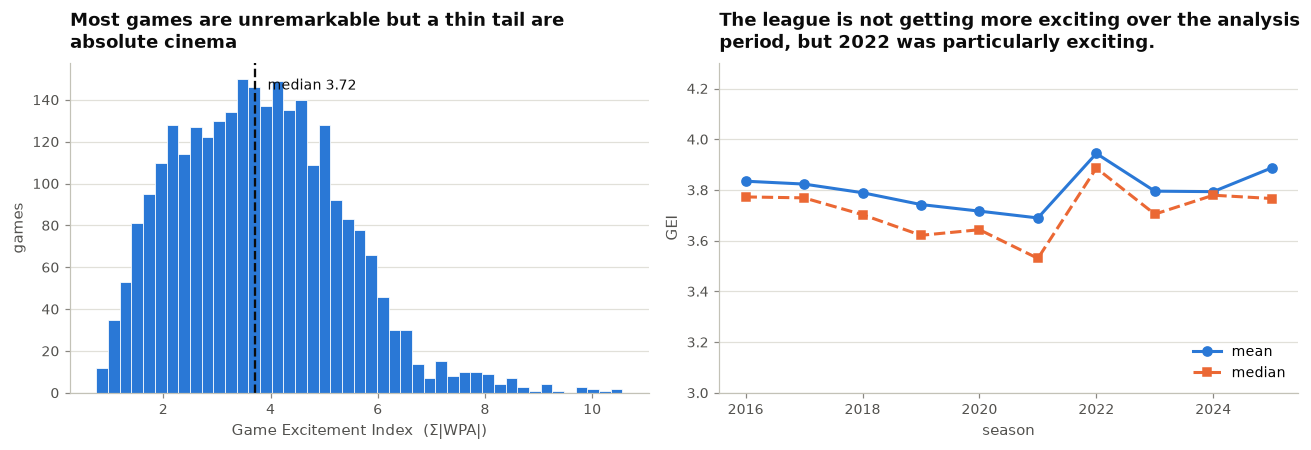

         mean  median  count
season                      
2016    3.835   3.773    267
2017    3.823   3.769    267
2018    3.789   3.703    267
2019    3.743   3.621    267
2020    3.717   3.643    269
2021    3.690   3.530    285
2022    3.944   3.886    284
2023    3.795   3.705    285
2024    3.793   3.779    285
2025    3.887   3.766    285


In [ ]:
# plot a summarization of the metrics
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].hist(games["gei"], bins=45, color=BLUE, edgecolor="white", linewidth=0.5)
med = games["gei"].median()
ax[0].axvline(med, color=INK, linewidth=1.5, linestyle="--")
ax[0].annotate(f"median {med:.2f}", (med, ax[0].get_ylim()[1] * 0.92),
               xytext=(8, 0), textcoords="offset points", color=INK, fontsize=9)
ax[0].set_title("Most games are unremarkable but a thin tail are \nabsolute cinema.")
ax[0].set_xlabel("Game Excitement Index  (Σ|WPA|)")
ax[0].set_ylabel("games")
tidy(ax[0])

season_gei = games.groupby("season")["gei"].agg(["mean", "median", "count"])
ax[1].plot(season_gei.index, season_gei["mean"], color=BLUE, linewidth=2,
           marker="o", markersize=6, label="mean")
ax[1].plot(season_gei.index, season_gei["median"], color=ORANGE, linewidth=2,
           marker="s", markersize=5, linestyle="--", label="median")
ax[1].set_ylim(3.0, 4.3)
ax[1].set_title("The league is not getting more exciting over the analysis\nperiod, but 2022 was particularly exciting.")
ax[1].set_xlabel("season")
ax[1].set_ylabel("GEI")
ax[1].legend(loc="lower right")
tidy(ax[1])

plt.tight_layout()
plt.show()
print(season_gei.round(3).to_string())

**Figure 1.** *Left:* the distribution of GEI across 2,761 games. The data is mildly right-skewed with a median game score of 3.72, but a thin tail runs past 10. *Right:* season means and medians.

The season plot answers a question worth asking: **is the NFL getting more exciting?** Across ten seasons the mean moves between 3.69 and 3.94 with no trend (a range of
about 6%), well inside season-to-season noise. Whatever has changed about the league in a decade of rule changes, the average amount of win-probability drama in a game has not.

This flatness is convenient for the modelling in §6 because it means we can pool data for ten seasons without worrying that we are averaging over an era-specific effect.

### 4.2 The 2025 season at a glance

The concept for the Figure below is carried forward from the Project Scoping Phase 1 assignment, but uses 2025 data rather than the original's 2019. Each tile is one game, positioned by week, shaded by GEI. The chart is generated by `show_excitement_chart()` in `src/plots.py`.

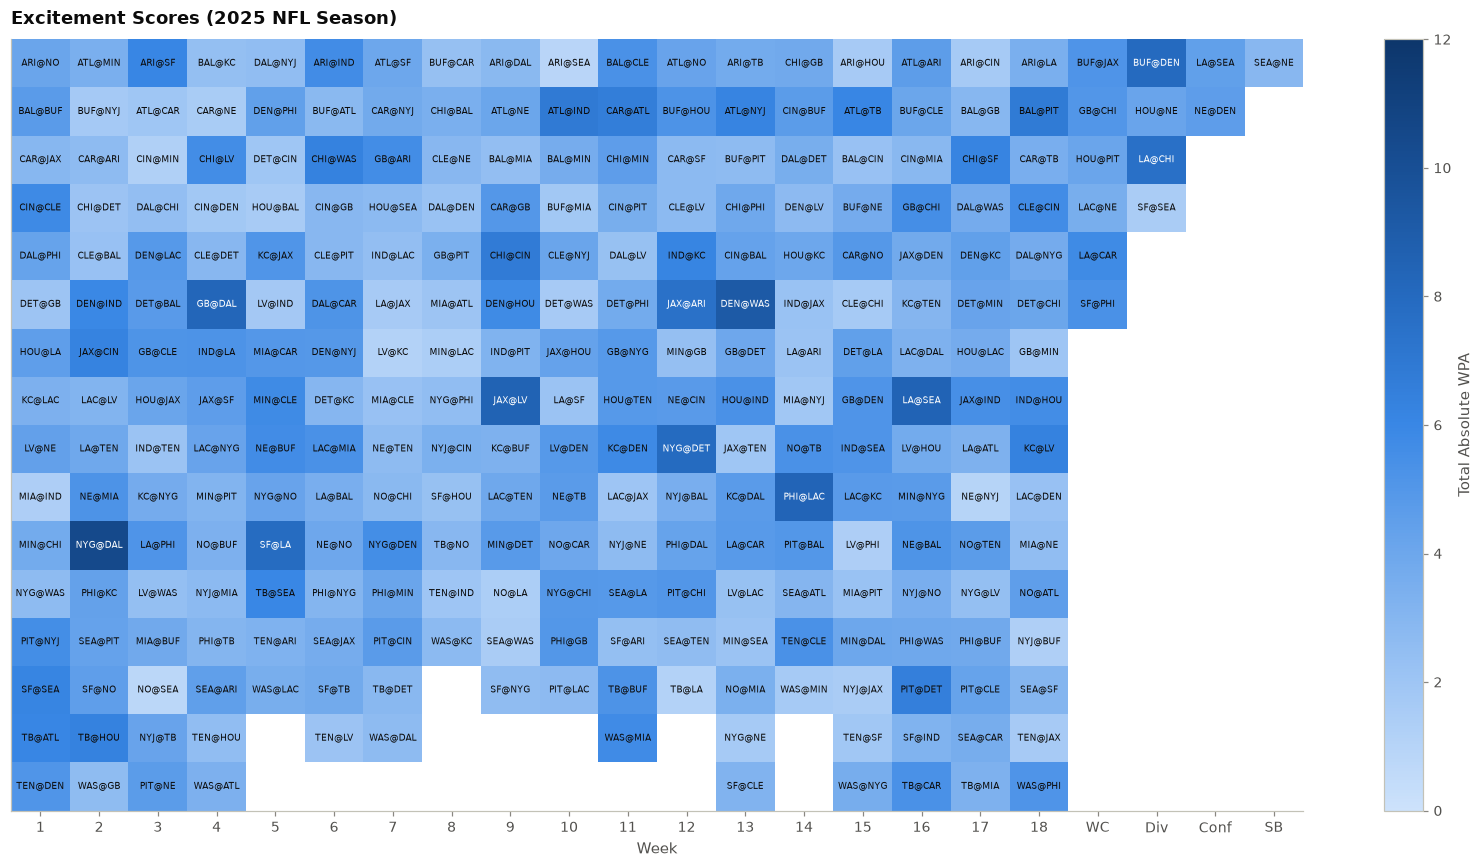

In [24]:
season_2025 = sched[sched.season == TEST_SEASON]
plays_2025 = pbp[pbp.season == TEST_SEASON]
show_excitement_chart(season_2025, plays_2025)

**Figure 2.** Every game of the 2025 season, shaded by GEI. Dark tiles are the games worth watching; the pale ones were over early.

The value of this view is that it makes a season scannable. Clusters of dark tiles mark weeks that delivered while a pale column is a week that did not. This view most directly provides a per-game grade for every game played. This view made it easy to recall a lived experience from week 2, watching the Dallas Cowboys defeat the New York Giants on a 60+ yard field goal to end the game as time hit zero in overtime.

### 4.3 Momentum charts: showing the two extremes of 2025

Phase 1 plotted a single game's win probability over time. The same code `show_wp_graph()` from `src/plots.py` is used to show the most and least exciting games of the held-out
(2025) season, the two ends of the distribution in Figure 1.

MOST exciting game of 2025: NYG @ DAL (week 2) | final 37-40 | GEI 10.44 | lead changes 7 | biggest single swing 0.50


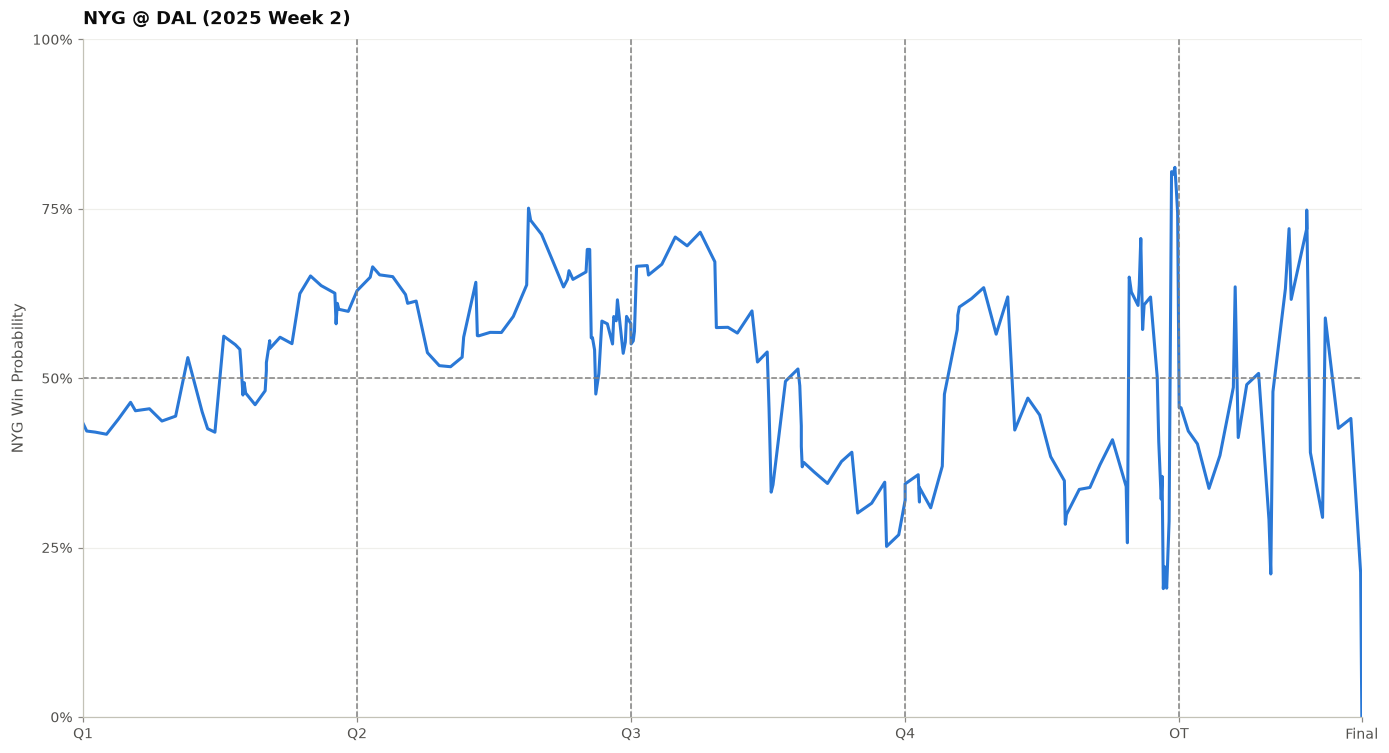

LEAST exciting game of 2025: NO @ SEA (week 3) | final 13-44 | GEI 0.75 | lead changes 0 | biggest single swing 0.08


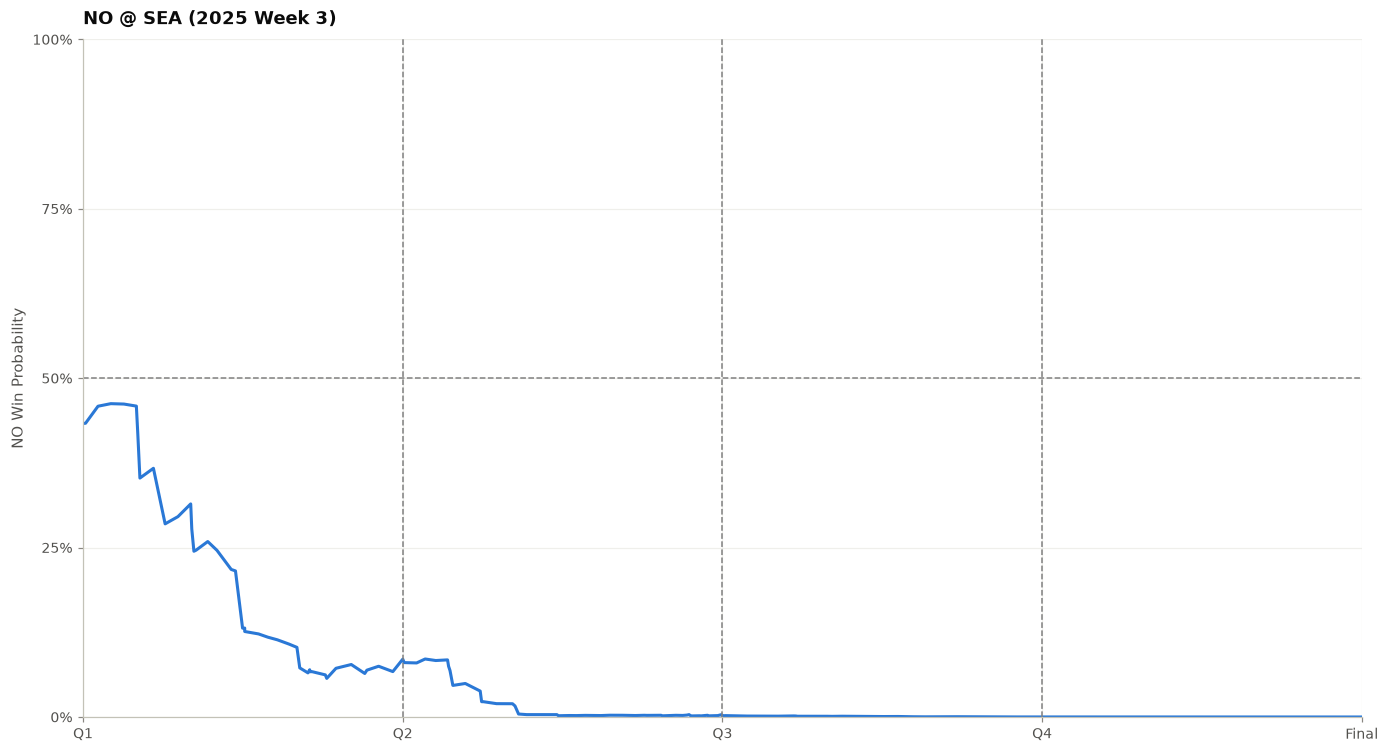

In [10]:
reg_2025 = games[(games.season == TEST_SEASON) & (games.game_type == "REG")]
best = reg_2025.loc[reg_2025.gei.idxmax()]
worst = reg_2025.loc[reg_2025.gei.idxmin()]

for label, row in (("MOST exciting", best), ("LEAST exciting", worst)):
    print(f"{label} game of {TEST_SEASON}: {row.matchup} (week {row.week:.0f}) "
          f"| final {row.away_score:.0f}-{row.home_score:.0f} | GEI {row.gei:.2f} "
          f"| lead changes {row.lead_changes:.0f} | biggest single swing {row.peak_swing:.2f}")
    show_wp_graph(sched[sched.game_id == row.game_id].iloc[0],
                  pbp[pbp.game_id == row.game_id])

**Figure 3.** Win-probability paths for the highest and lowest-GEI games of 2025.

The high-GEI game's line crosses and re-crosses the 50% WP axis, with several near-vertical drops with each one representing a play that flipped who
was expected to win. The low-GEI game's line commits early and never returns and by the second half, there is nothing left to decide.

Note that the top game went to overtime, which is not a coincidence. §5.1 shows it is a systematic property of GEI rather than a property of that game.

### 4.4 Which games are exciting?

Before modeling, we look at whether GEI varies with the things that are known before kickoff including the closing point spread, whether it is a division game, indoors or out, primetime or not, and how late in the season it is. This is a preview of §6 such that whatever signal exists here is likely the most a pre-game model could hope to find.

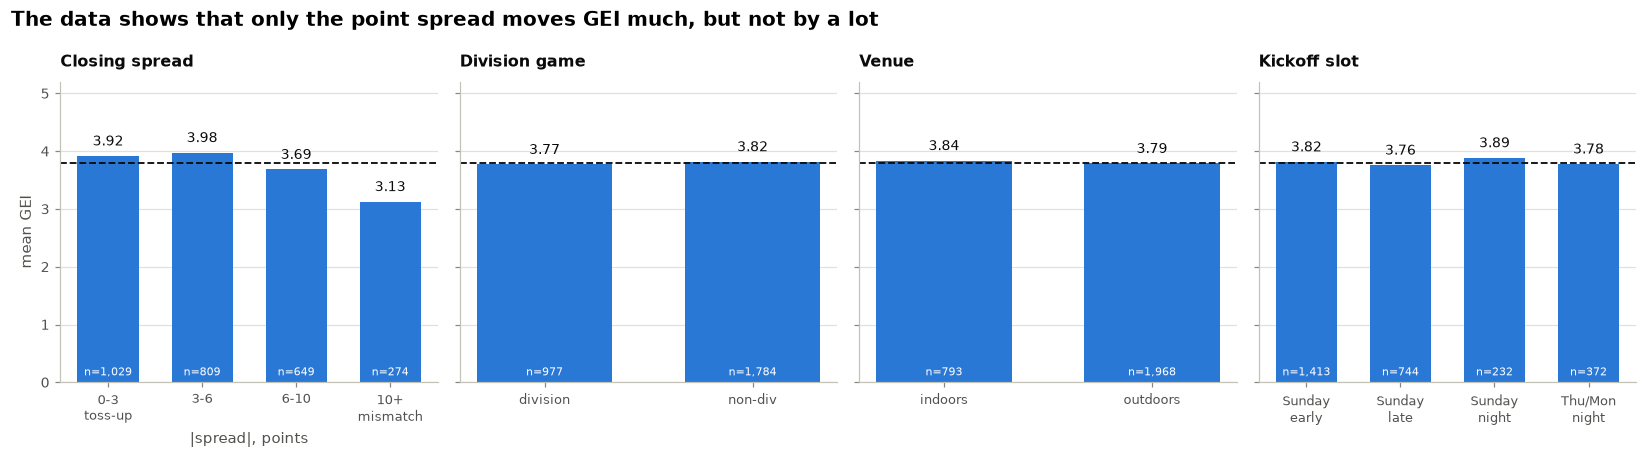

In [26]:
g = games.copy()
g["spread_bucket"] = pd.cut(g["spread_line"].abs(), [0, 3, 6, 10, 60],
                            labels=["0-3\ntoss-up", "3-6", "6-10", "10+\nmismatch"],
                            include_lowest=True)
hhmm = g["gametime"].str.split(":", expand=True).astype(float)
g["kick_hour"] = hhmm[0] + hhmm[1] / 60
g["slot"] = np.select(
    [g["weekday"].isin(["Thursday", "Monday"]), g["kick_hour"] >= 19.5, g["kick_hour"] >= 15.5],
    ["Thu/Mon\nnight", "Sunday\nnight", "Sunday\nlate"], default="Sunday\nearly")

# make some nice bars with labels
def bar_panel(ax, series, title, xlabel):
    vals, counts = series["mean"], series["count"]
    ax.bar(range(len(vals)), vals, color=BLUE, width=0.65)
    ax.axhline(games.gei.mean(), color=INK, linestyle="--", linewidth=1.2)
    for i, (v, c) in enumerate(zip(vals, counts)):
        # Offset clears the dashed overall-mean line, which sits near these bars.
        ax.text(i, v + 0.18, f"{v:.2f}", ha="center", fontsize=9, color=INK)
        ax.text(i, 0.12, f"n={c:,.0f}", ha="center", fontsize=7.5, color="white")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, fontsize=8.5)
    ax.set_ylim(0, 5.2)
    ax.set_title(title, fontsize=10.5)
    ax.set_xlabel(xlabel)
    tidy(ax)

fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharey=True)
bar_panel(axes[0], g.groupby("spread_bucket", observed=True)["gei"].agg(["mean", "count"]),
          "Closing spread", "|spread|, points")
bar_panel(axes[1], g.assign(d=np.where(g.div_game == 1, "division", "non-div"))
          .groupby("d")["gei"].agg(["mean", "count"]), "Division game", "")
bar_panel(axes[2], g.assign(r=np.where(g.roof.isin(["dome", "closed"]), "indoors", "outdoors"))
          .groupby("r")["gei"].agg(["mean", "count"]), "Venue", "")
bar_panel(axes[3], g.groupby("slot")["gei"].agg(["mean", "count"])
          .reindex(["Sunday\nearly", "Sunday\nlate", "Sunday\nnight", "Thu/Mon\nnight"]),
          "Kickoff slot", "")
axes[0].set_ylabel("mean GEI")
fig.suptitle("The data shows that only the point spread moves GEI much, but not by a lot",
             x=0.005, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Figure 4.** Mean GEI by pre-game context. The dashed line is the mean across all metrics (3.80).

Only one factor stands out:

- **The point spread matters, sort of.** Games the market called within a field goal average 3.92 and a double-digit mismatches average 3.13, about 20% less excitement. This is the single usable pre-game indicator in the dataset.
- **Division games, venue, and primetime are flat.** The rivalry premium that broadcasters assume for division games does not show up in win-probability movement. Neither does primetime, which is notable because primetime slots are assigned to games the league *expects* to be good. The league's own pre-game judgement produces no measurable edge.

The mismatch bar is a warning for §6: a 10+ point spread lowers the *average*, but the n=274 mismatches still include plenty of thrillers. A weak effect on a mean is not the same as a usable prediction for an individual game.

## 5. Data Analysis

### 5.1 Does GEI measure the claim?

GEI is built entirely out of a win-probability model, so it inherits that model's assumptions. It is tested three ways before building on top of it:

1. **Convergence against other metrics**: does it agree with independent descriptions of a good game?
2. **Face-value validity**: are the games it ranks highest recognisably great games?
3. **Failure modes**: where does it measure something other than excitement?

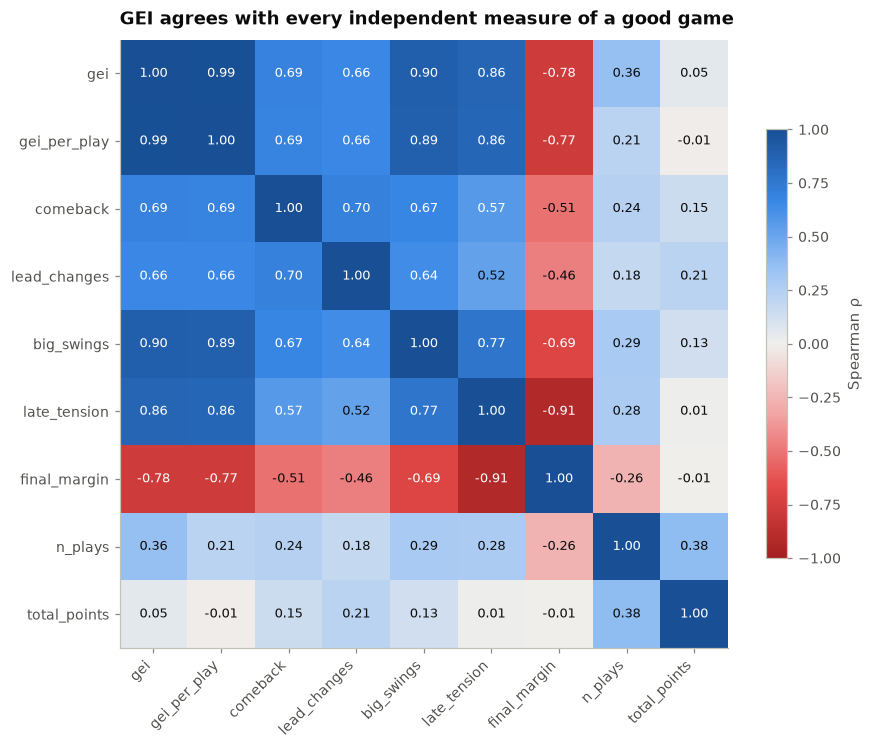

In [ ]:
# use spearman correlation to compare metrics from above

ALTS = ["gei", "gei_per_play", "comeback", "lead_changes", "big_swings",
        "late_tension", "final_margin", "n_plays", "total_points"]
corr = games[ALTS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.2, 6.8))
im = ax.imshow(corr, cmap=DIVERGING, norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1))
ax.set_xticks(range(len(ALTS))); ax.set_xticklabels(ALTS, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(ALTS))); ax.set_yticklabels(ALTS, fontsize=9)
for i in range(len(ALTS)):
    for j in range(len(ALTS)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if abs(v) > 0.55 else INK)
ax.set_title("GEI agrees with every independent measure of a good game")
fig.colorbar(im, ax=ax, shrink=0.7, label="Spearman p")
plt.tight_layout()
plt.show()

**Figure 5.** Spearman rank correlations. Blue is positive, red negative, grey ≈ 0.

**Convergence holds.** GEI agrees with four measures computed from different columns by different logic. It correlates 0.90 with the count of big swings, 0.86 with late-game tension, 0.69 with the size of the winner's comeback, and 0.66 with lead changes. As a sanity check, it is shown that it correlates −0.78 with final margin, which makes sense because blowouts are not exciting.

There are two items that deserve clarification:

- **`total_points` is uncorrelated with GEI (p = 0.05).** High-scoring games are not automatically good games. A 45–10 shootout is still a blowout. This is why GEI is built from win probability rather than scoring.
- **`n_plays` correlates 0.36 with GEI.** GEI is a *sum*, so longer games score higher partly for being longer. Normalising to `gei_per_play` cuts this to 0.21 while barely changing the ranking (the two correlate 0.99). This is the first sign of weakness in the GEI metric.

In [28]:
show = ["season", "week", "game_type", "matchup", "away_score", "home_score",
        "gei", "n_plays", "overtime", "lead_changes"]
print("TOP 10 GAMES BY GEI, 2016-2025")
print(games.nlargest(10, "gei")[show].to_string(index=False))
print("\nBOTTOM 5 GAMES BY GEI")
print(games.nsmallest(5, "gei")[show].to_string(index=False))

TOP 10 GAMES BY GEI, 2016-2025
 season  week game_type   matchup  away_score  home_score       gei  n_plays  overtime  lead_changes
   2020     3       REG CIN @ PHI          23          23 10.564183    224.0         1           3.0
   2025     2       REG NYG @ DAL          37          40 10.435559    221.0         1           7.0
   2021    10       REG DET @ PIT          16          16 10.197108    212.0         1           1.0
   2016     8       REG  OAK @ TB          30          24 10.096753    212.0         1           3.0
   2018     1       REG PIT @ CLE          21          21 10.019312    231.0         1           0.0
   2019    10       REG  SEA @ SF          27          24  9.786427    217.0         1           1.0
   2022     1       REG PIT @ CIN          23          20  9.784897    214.0         1           0.0
   2018     5       REG BAL @ CLE           9          12  9.749528    218.0         1           1.0
   2016     8       REG WAS @ CIN          27          27  9

**Face-value validity, and failure modes.** The bottom of the table matches expectations because every game is a lopsided blowout that stopped being a contest early. There is a subjective argument to be made, which is that fans of the winning team might find these events extremely exciting, as points (touchdowns), are valuable to the fan experience regardless of final outcome. A different reasonable metric might surface these contests as more exciting than a game that was 0-0 for most of regulation.

The top of the table highlights a problem with GEI. **All ten highest-GEI games went to overtime.** GEI is intended to rank games by drama, and near the top it has instead ranked them by whether they needed extra time.

             n  mean_gei  mean_plays  mean_per_play
overtime                                           
0         2607     3.619     173.987          0.021
1          154     6.900     199.156          0.035

overtime share of all games          5.6%
overtime share of top-50 by GEI    100.0%
overtime share of top-50 by GEI_reg 20.0%   <- regulation-only


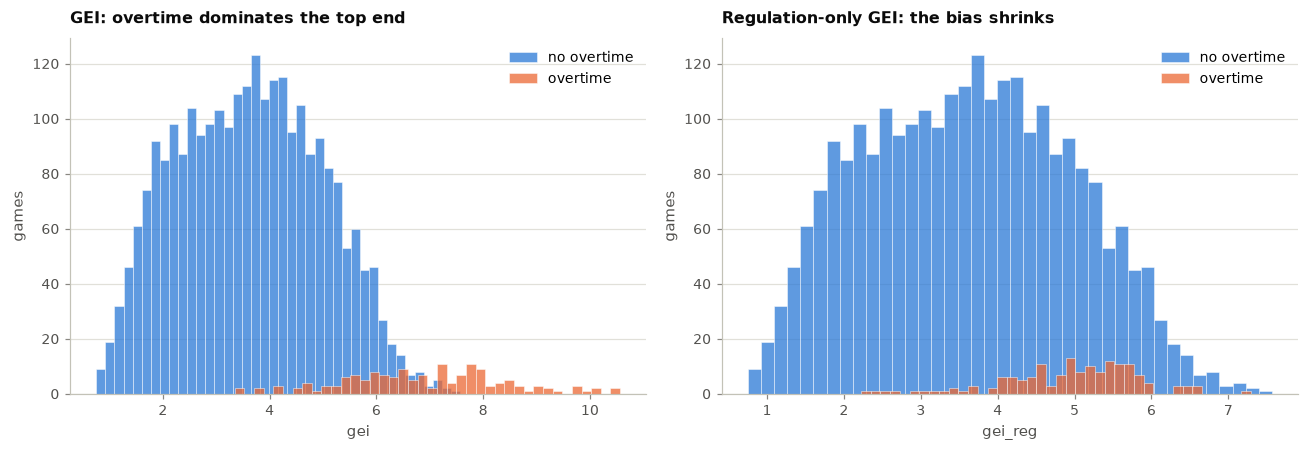

In [29]:
ot = games.groupby("overtime").agg(
    n=("gei", "size"), mean_gei=("gei", "mean"),
    mean_plays=("n_plays", "mean"), mean_per_play=("gei_per_play", "mean"))
print(ot.round(3).to_string())

top50_ot = games.nlargest(50, "gei")["overtime"].mean()
top50_ot_reg = games.nlargest(50, "gei_reg")["overtime"].mean()
print(f"\novertime share of all games        {games.overtime.mean():6.1%}")
print(f"overtime share of top-50 by GEI    {top50_ot:6.1%}")
print(f"overtime share of top-50 by GEI_reg{top50_ot_reg:6.1%}   <- regulation-only")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a, col, title in ((ax[0], "gei", "GEI: overtime dominates the top end"),
                      (ax[1], "gei_reg", "Regulation-only GEI: the bias shrinks")):
    for flag, colour, name in ((0, BLUE, "no overtime"), (1, ORANGE, "overtime")):
        a.hist(games.loc[games.overtime == flag, col], bins=40, alpha=0.75,
               color=colour, label=name, edgecolor="white", linewidth=0.4)
    a.set_title(title, fontsize=10.5)
    a.set_xlabel(col); a.set_ylabel("games"); a.legend(); tidy(a)
plt.tight_layout()
plt.show()

**Figure 6.** GEI (left) versus regulation-only GEI (right), split by whether the game went to overtime.

Overtime games average nearly 2x GEI, **6.90 against 3.62** for the rest. Only 5.6% of games go to overtime, yet they take **100%** of the top 50 slots. The mechanism is straight forward: overtime was historically sudden-death football, played entirely at a coin-flip win probability, so every play generates large WPA, and GEI adds that to a total that already counts a full regulation game. Note that a 2022 rule change allows both teams a posession in the regular season, with adoption for playoffs in 2025.

Restricting the sum to regulation (`gei_reg`) drops overtime's share of the top 50 to **20%** which is a more defensible number, since a game that stays tied through sixty minutes was likely to be dramatic.

It can be concluded that GEI is valid as a measure of *total drama delivered*, which is the right quantity for "was this worth watching". It is not a measure of drama *per minute*, and it is a poor measure to compare an overtime game against a regulation without recognizing this nuance. GEI is kept as the headline metric because the viewer's question is about the whole broadcast, and the bias is noted. Section 6.1 re-runs its main model against `gei_reg` to confirm the conclusions do not depend on the choice.

### 5.2 What actually wins football games?

Four metrics were ranked by their correlation with winning in Phase 1. Correlations taken one at a time are a weak tool when the predictors overlap and these predictors overlapped almost completely, since EPA per play, success rate, and explosive-play rate are three ways of asking "did the offense do well?"

Logistic regression is used as an upgrade that sees all the features at once, trained on 2016–2024 and scored on 2025.

In [ ]:
# setup for logistic regression - feature engineering for metrics that win football games
scrim = pbp[pbp["play_type"].isin(["run", "pass"])].copy()
scrim["explosive"] = (scrim["yards_gained"] >= 15).astype(float)

team_game = scrim.groupby(["game_id", "posteam"]).agg(
    epa_per_play=("epa", "mean"),
    success_rate=("success", "mean"),
    explosive_rate=("explosive", "mean"),
    interceptions=("interception", "sum"),
    fumbles_lost=("fumble_lost", "sum"),
    n_plays=("epa", "size"),
).reset_index()
team_game["turnovers"] = team_game["interceptions"] + team_game["fumbles_lost"]

third = (pbp[pbp["down"] == 3].groupby(["game_id", "posteam"])["third_down_converted"]
         .mean().rename("third_down_rate").reset_index())
team_game = team_game.merge(third, on=["game_id", "posteam"], how="left")

team_game = team_game.merge(
    sched[["game_id", "season", "week", "home_team", "home_score", "away_score"]], on="game_id")
team_game["is_home"] = (team_game["posteam"] == team_game["home_team"]).astype(float)
team_game["team_score"] = np.where(team_game.is_home == 1, team_game.home_score, team_game.away_score)
team_game["opp_score"] = np.where(team_game.is_home == 1, team_game.away_score, team_game.home_score)

ties = (team_game.team_score == team_game.opp_score).sum()
team_game = team_game[team_game.team_score != team_game.opp_score].copy()
team_game["win"] = (team_game.team_score > team_game.opp_score).astype(int)

WIN_FEATS = ["epa_per_play", "success_rate", "explosive_rate", "turnovers",
             "third_down_rate", "is_home"]
team_game = team_game.dropna(subset=WIN_FEATS)
print(f"{len(team_game):,} team-games ({ties} tie rows dropped: no win label)")
print(team_game[WIN_FEATS].describe().round(3).to_string())

5,502 team-games (20 tie rows dropped: no win label)
       epa_per_play  success_rate  explosive_rate  turnovers  third_down_rate   is_home
count      5502.000      5502.000        5502.000   5502.000         5502.000  5502.000
mean         -0.003         0.434           0.107      1.240            0.359     0.493
std           0.206         0.075           0.041      1.165            0.133     0.500
min          -0.832         0.121           0.000      0.000            0.000     0.000
25%          -0.133         0.384           0.078      0.000            0.267     0.000
50%           0.008         0.435           0.104      1.000            0.357     0.000
75%           0.136         0.485           0.133      2.000            0.455     1.000
max           0.768         0.686           0.275      7.000            0.857     1.000


In [32]:
# run logistic regression and output summary metrics and confusion matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, brier_score_loss,
                             confusion_matrix, accuracy_score)

wtr = team_game[team_game.season.isin(TRAIN_SEASONS)]
wte = team_game[team_game.season == TEST_SEASON]

win_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
win_model.fit(wtr[WIN_FEATS], wtr["win"])
win_p = win_model.predict_proba(wte[WIN_FEATS])[:, 1]

win_auc = roc_auc_score(wte["win"], win_p)
win_acc = accuracy_score(wte["win"], win_p > 0.5)
win_brier = brier_score_loss(wte["win"], win_p)

print(f"train {len(wtr):,} team-games ({TRAIN_SEASONS[0]}-{TRAIN_SEASONS[-1]})"
      f"  |  test {len(wte):,} ({TEST_SEASON})\n")
print(f"  ROC-AUC   {win_auc:.3f}   (0.5 = coin flip)")
print(f"  Accuracy  {win_acc:.3f}   (0.5 = coin flip)")
print(f"  Brier     {win_brier:.3f}   (0.25 = always predict 50%)")
cm = confusion_matrix(wte["win"], (win_p > 0.5).astype(int))
print("\nconfusion matrix (rows = actual loss/win, cols = predicted):")
print(pd.DataFrame(cm, index=["actual L", "actual W"], columns=["pred L", "pred W"]).to_string())

train 4,934 team-games (2016-2024)  |  test 568 (2025)

  ROC-AUC   0.811   (0.5 = coin flip)
  Accuracy  0.724   (0.5 = coin flip)
  Brier     0.178   (0.25 = always predict 50%)

confusion matrix (rows = actual loss/win, cols = predicted):
          pred L  pred W
actual L     197      87
actual W      70     214


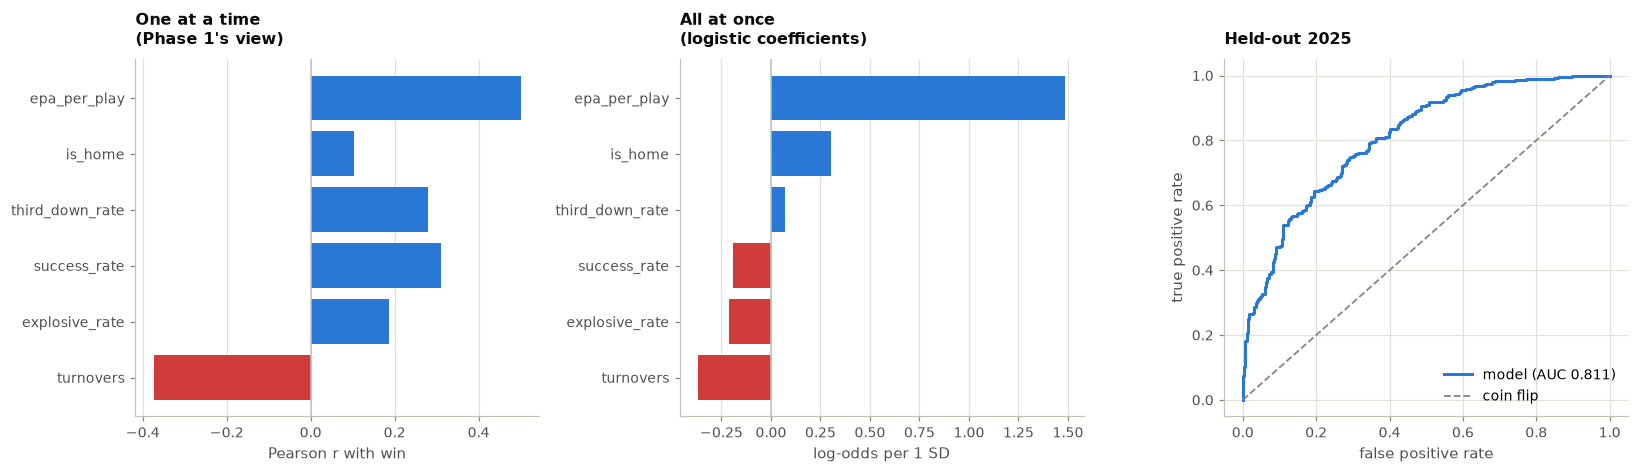

                 marginal_corr  model_coef
turnovers               -0.374      -0.367
explosive_rate           0.187      -0.213
success_rate             0.310      -0.192
third_down_rate          0.278       0.069
is_home                  0.104       0.305
epa_per_play             0.500       1.486


In [33]:
# generate plots that compare the phase 1 approach to the logistic regression upgrade
marginal = wtr[WIN_FEATS + ["win"]].corr()["win"].drop("win")
multi = pd.Series(win_model[-1].coef_[0], index=WIN_FEATS)
comp = pd.DataFrame({"marginal_corr": marginal, "model_coef": multi}).sort_values("model_coef")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

ax[0].barh(comp.index, comp.marginal_corr,
           color=[RED if v < 0 else BLUE for v in comp.marginal_corr])
ax[0].axvline(0, color=BASELINE, linewidth=1)
ax[0].set_title("One at a time\n(Phase 1's view)", fontsize=10.5)
ax[0].set_xlabel("Pearson r with win")
tidy(ax[0], "x")

ax[1].barh(comp.index, comp.model_coef,
           color=[RED if v < 0 else BLUE for v in comp.model_coef])
ax[1].axvline(0, color=BASELINE, linewidth=1)
ax[1].set_title("All at once\n(logistic coefficients)", fontsize=10.5)
ax[1].set_xlabel("log-odds per 1 SD")
tidy(ax[1], "x")

fpr, tpr, _ = roc_curve(wte["win"], win_p)
ax[2].plot(fpr, tpr, color=BLUE, linewidth=2, label=f"model (AUC {win_auc:.3f})")
ax[2].plot([0, 1], [0, 1], color=INK_MUTED, linestyle="--", linewidth=1.2, label="coin flip")
ax[2].set_xlabel("false positive rate"); ax[2].set_ylabel("true positive rate")
ax[2].set_title(f"Held-out {TEST_SEASON}", fontsize=10.5)
ax[2].legend(loc="lower right"); tidy(ax[2], "both")

plt.tight_layout()
plt.show()
print(comp.round(3).to_string())

**Figure 7.** The same six features viewed marginally as in Phase 1(left), jointly (middle), and the model's performance against the 2025 data (right).

**The model works.** On 568 team-games it never saw, it reaches **AUC 0.811** and **72.4% accuracy**, with a Brier score of 0.178 against 0.25 for an uninformed guess. Given that it sees only six aggregate numbers and nothing about who was playing. The result confirms Phase 1's conclusion that EPA per play is the dominant success metric at **+1.49 log-odds per standard deviation**, signficantly more informative than everything else.

**The Phase 1 and new approaches disagree**. Marginally, success rate (+0.31) and explosive-play rate (+0.19) look like indicators. In the joint model both turn *negative*. This is not a contradiction and it does not mean explosive plays lose games but rather it shows collinearity. EPA per play already contains almost everything success rate and explosive rate measure, so once EPA is in the model, what is left of those variables is the residual. Teams whose success rate was high relative to their EPA, i.e. offences that moved the chains steadily without generating much value per play, do slightly worse.

The takeaway provides caution about the Phase 1 method in that a bar chart of marginal correlations invites unsupportable causal reading. Showing the plots side by side
makes the difference more directly visible.

Home-field advantage survives as a real but small effect (+0.31 log-odds per SD), consistent with the modest home win rate Phase 1 found.

## 6. Models

### 6.1 Can excitement be predicted before kickoff?

With sufficent exploration and data preparation, the guiding question can be addressed. Everything so far has been retrospective, GEI can only be computed once a game is over. The commercially and practically interesting question is whether the same number can be forecasted from information known at or before kickoff.

**Features.** All available before the game starts:

| Feature | Source |
|---|---|
| `abs_spread`, `total_line` | Closing betting market, the market's own forecast of closeness and scoring |
| `combined_form`, `form_gap`, `def_form_mean` | Rolling team EPA form from earlier games this season |
| `rest_diff`, `week` | Schedule structure |
| `div_game`, `is_dome`, `primetime`, `kick_hour` | Matchup and TV slot context |
| `temp`, `wind` | Forecastable weather |

Features use an expanding mean over each team's *prior* games in the same season, shifted by one game, as a means to control leakage.

In [34]:
# Rolling form, strictly from prior games within the same season.
form = team_game[["game_id", "posteam", "season", "week", "epa_per_play"]].copy()
form = form.sort_values(["season", "posteam", "week"])
form["off_form"] = (form.groupby(["season", "posteam"])["epa_per_play"]
                    .transform(lambda s: s.shift(1).expanding().mean()))

# Defensive form: how the opponent's offence performed against this team, prior games only.
pair = form.merge(form, on="game_id", suffixes=("", "_opp"))
pair = pair[pair.posteam != pair.posteam_opp].sort_values(["season", "posteam", "week"])
pair["def_form"] = (pair.groupby(["season", "posteam"])["epa_per_play_opp"]
                    .transform(lambda s: s.shift(1).expanding().mean()))
form = form.merge(pair[["game_id", "posteam", "def_form"]], on=["game_id", "posteam"], how="left")

side = form[["game_id", "posteam", "off_form", "def_form"]]
mdf = games.merge(side.rename(columns={"posteam": "home_team", "off_form": "home_off_form",
                                       "def_form": "home_def_form"}),
                  on=["game_id", "home_team"], how="left")
mdf = mdf.merge(side.rename(columns={"posteam": "away_team", "off_form": "away_off_form",
                                     "def_form": "away_def_form"}),
                on=["game_id", "away_team"], how="left")

mdf["abs_spread"] = mdf["spread_line"].abs()
mdf["rest_diff"] = mdf["home_rest"] - mdf["away_rest"]
mdf["is_dome"] = mdf["roof"].isin(["dome", "closed"]).astype(float)
mdf["div_game"] = mdf["div_game"].astype(float)
_hm = mdf["gametime"].str.split(":", expand=True).astype(float)
mdf["kick_hour"] = _hm[0] + _hm[1] / 60
mdf["primetime"] = ((mdf.kick_hour >= 19.5) |
                    (mdf.weekday.isin(["Thursday", "Monday"]))).astype(float)
mdf["combined_form"] = mdf[["home_off_form", "away_off_form"]].mean(axis=1)
mdf["form_gap"] = (mdf.home_off_form - mdf.away_off_form).abs()
mdf["def_form_mean"] = mdf[["home_def_form", "away_def_form"]].mean(axis=1)
# Indoors, temp/wind are filles with the controlled condition rather than the outdoor median.
mdf["temp"] = np.where(mdf.is_dome == 1, 70.0, mdf.temp)
mdf["wind"] = np.where(mdf.is_dome == 1, 0.0, mdf.wind)

PRE_FEATS = ["abs_spread", "total_line", "rest_diff", "div_game", "is_dome", "primetime",
             "week", "kick_hour", "combined_form", "form_gap", "def_form_mean", "temp", "wind"]
mdf = mdf.dropna(subset=["gei", "abs_spread", "total_line"]).copy()
print(f"{len(mdf):,} games with complete pre-game features")

2,761 games with complete pre-game features


In [37]:
# optionally verify that form for game G uses only strictly earlier games
gd = games.set_index("game_id")["gameday"]
violations = 0
checked = 0
for gid in form.game_id.unique():
    for _, r in form[form.game_id == gid].iterrows():
        prior = form[(form.posteam == r.posteam) & (form.season == r.season) &
                     (form.week < r.week)]
        checked += 1
        expected = prior["epa_per_play"].mean() if len(prior) else np.nan
        got = r["off_form"]
        if not (np.isnan(expected) and np.isnan(got)) and not np.isclose(expected, got, equal_nan=True):
            violations += 1
        # every contributing game must be strictly earlier
        if len(prior) and prior["week"].max() >= r["week"]:
            violations += 1

print(f"checked {checked} team-game form values across all games")
print(f"leakage violations: {violations}")
assert violations == 0, "rolling form leaks information from the current or future games"
print("PASS - form features use only strictly prior games in the same season")

checked 5502 team-game form values across all games
leakage violations: 0
PASS - form features use only strictly prior games in the same season


In [38]:
# train various models to extract results from the dataset
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score,
                             average_precision_score)

def fit_and_score(train, test, target="gei"):
    """Regression + classification on one season split. Returns a dict of metrics."""
    Xtr, Xte = train[PRE_FEATS], test[PRE_FEATS]
    med = Xtr.median()
    ytr, yte = train[target], test[target]
    thr = ytr.quantile(0.75)
    ctr, cte = (ytr >= thr).astype(int), (yte >= thr).astype(int)
    out = {"n_train": len(train), "n_test": len(test), "threshold": thr}

    base = np.full(len(yte), ytr.mean())
    out["base_mae"] = mean_absolute_error(yte, base)
    out["base_rmse"] = root_mean_squared_error(yte, base)

    ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 20)))
    ridge.fit(Xtr.fillna(med), ytr)
    pr = ridge.predict(Xte.fillna(med))
    out.update(ridge_mae=mean_absolute_error(yte, pr), ridge_rmse=root_mean_squared_error(yte, pr),
               ridge_r2=r2_score(yte, pr))

    hgr = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=400,
                                        random_state=RANDOM_STATE).fit(Xtr, ytr)
    ph = hgr.predict(Xte)
    out.update(hgb_mae=mean_absolute_error(yte, ph), hgb_rmse=root_mean_squared_error(yte, ph),
               hgb_r2=r2_score(yte, ph))

    logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    logit.fit(Xtr.fillna(med), ctr)
    pl = logit.predict_proba(Xte.fillna(med))[:, 1]
    out.update(logit_auc=roc_auc_score(cte, pl), logit_ap=average_precision_score(cte, pl),
               logit_brier=brier_score_loss(cte, pl))

    hgc = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=400,
                                         random_state=RANDOM_STATE).fit(Xtr, ctr)
    pc = hgc.predict_proba(Xte)[:, 1]
    out.update(hgb_auc=roc_auc_score(cte, pc), hgb_ap=average_precision_score(cte, pc))

    spread_only = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    spread_only.fit(Xtr[["abs_spread"]], ctr)
    out["spread_auc"] = roc_auc_score(cte, spread_only.predict_proba(Xte[["abs_spread"]])[:, 1])
    out["base_rate"] = cte.mean()
    out["_ridge"] = ridge
    return out

pre_tr = mdf[mdf.season.isin(TRAIN_SEASONS)]
pre_te = mdf[mdf.season == TEST_SEASON]
single = fit_and_score(pre_tr, pre_te)

print(f"HEADLINE SPLIT — train {single['n_train']:,} games, test {single['n_test']} "
      f"({TEST_SEASON})\n")
print("Regression, target = GEI")
print(f"{'model':<26}{'MAE':>8}{'RMSE':>8}{'R2':>8}")
print(f"{'baseline (train mean)':<26}{single['base_mae']:>8.3f}{single['base_rmse']:>8.3f}"
      f"{0.0:>8.3f}")
print(f"{'RidgeCV':<26}{single['ridge_mae']:>8.3f}{single['ridge_rmse']:>8.3f}"
      f"{single['ridge_r2']:>8.3f}")
print(f"{'HistGradientBoosting':<26}{single['hgb_mae']:>8.3f}{single['hgb_rmse']:>8.3f}"
      f"{single['hgb_r2']:>8.3f}")
print(f"\nClassification, target = thriller (GEI >= {single['threshold']:.2f}, "
      f"train 75th pct); test base rate {single['base_rate']:.3f}")
print(f"{'model':<26}{'AUC':>8}{'PR-AUC':>9}")
print(f"{'baseline':<26}{0.5:>8.3f}{single['base_rate']:>9.3f}")
print(f"{'Logistic (13 features)':<26}{single['logit_auc']:>8.3f}{single['logit_ap']:>9.3f}")
print(f"{'HistGradientBoosting':<26}{single['hgb_auc']:>8.3f}{single['hgb_ap']:>9.3f}")
print(f"{'Logistic (spread only)':<26}{single['spread_auc']:>8.3f}")

HEADLINE SPLIT — train 2,476 games, test 285 (2025)

Regression, target = GEI
model                          MAE    RMSE      R2
baseline (train mean)        1.321   1.657   0.000
RidgeCV                      1.305   1.639   0.018
HistGradientBoosting         1.340   1.675  -0.026

Classification, target = thriller (GEI >= 4.81, train 75th pct); test base rate 0.284
model                          AUC   PR-AUC
baseline                     0.500    0.284
Logistic (13 features)       0.480    0.284
HistGradientBoosting         0.452    0.255
Logistic (spread only)       0.544


On the single held-out 2025 season, the models are **worse than useless**: R^2 of 0.02 for Ridge and negative for the boosted tree with classification AUCs of 0.48 and 0.45, both below the 0.50 of a coin flip.

It would be easy to stop here and declare excitement unpredictable. But a single 285-game season is a small test set, and §4.4 showed spread effects in the full data. Before concluding, it is worthwhile to check whether this result is stable or just one noisy season.

In [40]:
wf = []
for s in range(2020, TEST_SEASON + 1):
    r = fit_and_score(mdf[mdf.season < s], mdf[mdf.season == s])
    r["test_season"] = s
    wf.append(r)
wf = pd.DataFrame(wf).set_index("test_season")

cols = ["ridge_r2", "base_mae", "ridge_mae", "logit_auc", "hgb_auc", "spread_auc"]
summary = wf[cols].copy()
summary.loc["MEAN"] = wf[cols].mean()
summary.loc["SD"] = wf[cols].std()
print("WALKING VALIDATION (train on all prior seasons, test on one)\n")
print(summary.round(3).to_string())

WALKING VALIDATION (train on all prior seasons, test on one)

             ridge_r2  base_mae  ridge_mae  logit_auc  hgb_auc  spread_auc
test_season                                                               
2020            0.003     1.173      1.168      0.559    0.472       0.485
2021            0.027     1.284      1.270      0.649    0.550       0.617
2022           -0.006     1.198      1.187      0.543    0.542       0.547
2023            0.022     1.262      1.234      0.567    0.585       0.574
2024            0.003     1.234      1.237      0.456    0.529       0.508
2025            0.018     1.321      1.305      0.480    0.452       0.544
MEAN            0.011     1.245      1.233      0.542    0.522       0.546
SD              0.013     0.055      0.051      0.069    0.050       0.047


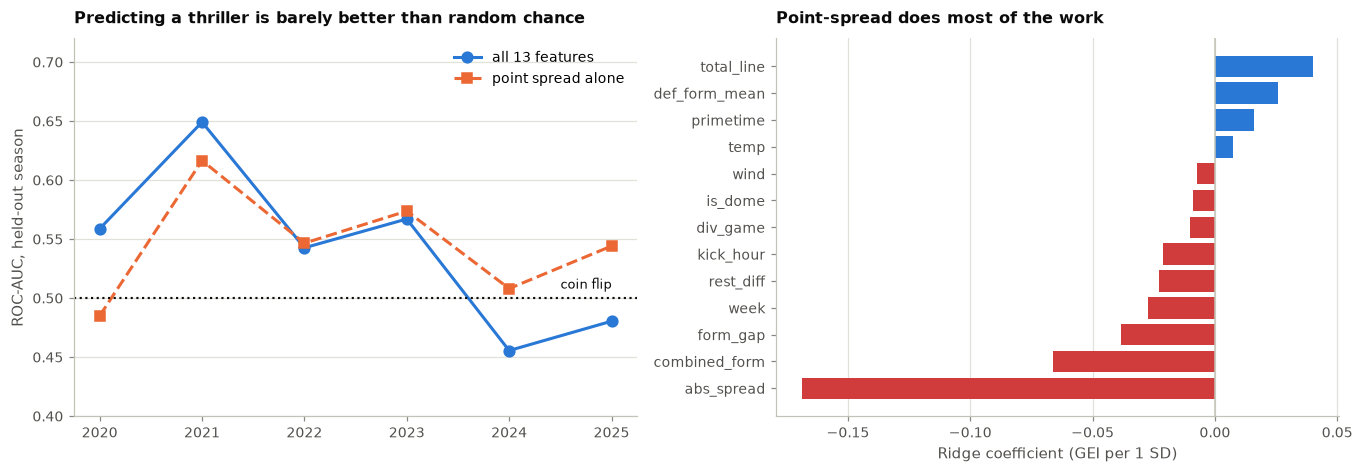

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))

seasons_wf = wf.index.tolist()
ax[0].plot(seasons_wf, wf.logit_auc, color=BLUE, marker="o", linewidth=2,
           markersize=7, label="all 13 features")
ax[0].plot(seasons_wf, wf.spread_auc, color=ORANGE, marker="s", linewidth=2,
           markersize=6, linestyle="--", label="point spread alone")
ax[0].axhline(0.5, color=INK, linewidth=1.4, linestyle=":")
ax[0].text(seasons_wf[-1], 0.508, "coin flip", fontsize=8.5, color=INK, ha="right")
ax[0].set_ylim(0.40, 0.72)
ax[0].set_xticks(seasons_wf)
ax[0].set_ylabel("ROC-AUC, held-out season")
ax[0].set_title("Predicting a thriller is barely better than random chance", fontsize=10.5)
ax[0].legend(loc="upper right")
tidy(ax[0])

ridge_coef = pd.Series(single["_ridge"][-1].coef_, index=PRE_FEATS).sort_values()
ax[1].barh(ridge_coef.index, ridge_coef.values,
           color=[RED if v < 0 else BLUE for v in ridge_coef.values])
ax[1].axvline(0, color=BASELINE, linewidth=1)
ax[1].set_xlabel("Ridge coefficient (GEI per 1 SD)")
ax[1].set_title("Point-spread does most of the work", fontsize=10.5)
tidy(ax[1], "x")

plt.tight_layout()
plt.show()

**Figure 8.** *Left:* AUC by test (held-out) season, for the full model and for the point spread
alone. *Right:* Ridge coefficients.

**The walking view changes the conclusion twice.**

First, 2025 was not representative. Averaged over six held-out seasons the full model reaches **AUC 0.542 (SD 0.069)** and Ridge reaches **R² 0.011**. So there is indeed a signal, and it is consistently positive in four of six seasons, meaning the single-split result of 0.48 was in the noise. This shows using one season could have produced a confidently wrong answer in either direction.

Second, the signal is tiny and is nearly entirely the point spread. The spread on its own averages **AUC 0.546** which is indistinguishable from, and marginally better than, the full thirteen-feature model. Rest, weather, division rivalry, primetime slot, team form, and kickoff time contribute nothing of note. The Ridge coefficients agree: `abs_spread` is about two and a half times the size of the next-largest term, and negative. Closer games are more exciting, which is what §4.4 already showed.

An AUC of 0.54 indicates a real effect but a useless ability to forecast. Concretely, knowing the closing spread lets you rank a pair of games correctly 54% of the time instead of 50%. Ridge explains about 1% of the variance in GEI, but the remaining 99% is what happens on the field.

**A conclusion is made from the negative result with confidence:** *NFL game excitement is largely unpredictable before kickoff.* The betting market, the most efficient aggregator of pre-game information that exists, can tell you who will probably win, but not whether the game will be worth watching.

This has a direct implications for the league office. Flex scheduling cannot reliably move good games into primetime, because the information required does not exist at the decision point. It should be noted that there are other reasons for moving a game into primetime, such as expected viewership due to each team's market size and the league's media marketing can artifically make the game excitement peak before and during the broadcast in ways not directly tied to the quality of the match on the field. 

In [46]:
# Robustness: does the conclusion depend on GEI's overtime bias (5.1)?
alt = pd.DataFrame([fit_and_score(mdf[mdf.season < s], mdf[mdf.season == s], target="gei_reg")
                    | {"test_season": s} for s in range(2020, TEST_SEASON + 1)]
                   ).set_index("test_season")
print("Walking with target = REGULATION-ONLY GEI\n")
print(f"  mean Ridge R2   {alt.ridge_r2.mean():.3f}  (GEI: {wf.ridge_r2.mean():.3f})")
print(f"  mean logit AUC  {alt.logit_auc.mean():.3f}  (GEI: {wf.logit_auc.mean():.3f})")
print(f"  mean spread AUC {alt.spread_auc.mean():.3f}  (GEI: {wf.spread_auc.mean():.3f})")
print("\nThe conclusion is unchanged: still barely above random chance either way.")

Walking with target = REGULATION-ONLY GEI

  mean Ridge R2   0.012  (GEI: 0.011)
  mean logit AUC  0.534  (GEI: 0.542)
  mean spread AUC 0.545  (GEI: 0.546)

The conclusion is unchanged: still barely above random chance either way.


Re-running the whole walk against regulation-only GEI gives the same answer. The unpredictability finding is a property of football, not an artifact of how overtime was handled.

### 6.2 What kinds of games are there?

GEI compresses a game to one number, which necessarily discards *how* it got there. A 24–21 game decided by a last-minute field goal and a 24–21 game where the winner led throughout can score similarly. Unsupervised learning is used to recover the shapes and gain deeper insights. Each game is described by eight features of its win-probability path, standardised, then projected with PCA for visualisation and grouped with KMeans.

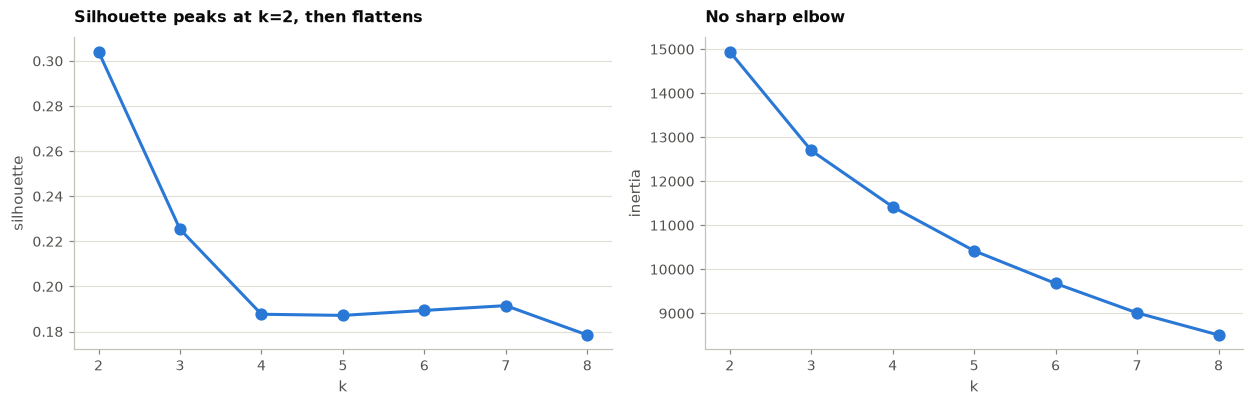

  k=2  silhouette 0.304
  k=3  silhouette 0.225
  k=4  silhouette 0.188
  k=5  silhouette 0.187
  k=6  silhouette 0.189
  k=7  silhouette 0.192
  k=8  silhouette 0.178


In [47]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SHAPE_FEATS = ["winner_trailed_frac", "competitive_frac", "peak_swing", "q4_volatility",
               "wp_std", "lead_changes", "final_margin", "total_points"]
Xs = StandardScaler().fit_transform(games[SHAPE_FEATS].fillna(games[SHAPE_FEATS].median()))

ks = range(2, 9)
sil = [silhouette_score(Xs, KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
                        .fit_predict(Xs), sample_size=2000, random_state=RANDOM_STATE)
       for k in ks]
inertia = [KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Xs).inertia_ for k in ks]

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax[0].plot(list(ks), sil, color=BLUE, marker="o", linewidth=2, markersize=7)
ax[0].set_xlabel("k"); ax[0].set_ylabel("silhouette")
ax[0].set_title("Silhouette peaks at k=2, then flattens", fontsize=10.5); tidy(ax[0])
ax[1].plot(list(ks), inertia, color=BLUE, marker="o", linewidth=2, markersize=7)
ax[1].set_xlabel("k"); ax[1].set_ylabel("inertia")
ax[1].set_title("No sharp elbow", fontsize=10.5); tidy(ax[1])
plt.tight_layout(); plt.show()

for k, s in zip(ks, sil):
    print(f"  k={k}  silhouette {s:.3f}")

**Figure 9.** Cluster-count diagnostics.

Silhouette peaks at k = 2 (0.30) and settles around 0.19 thereafter, and the inertia curve has no elbow. Both metrics inform that game shape is a continuum, not a set of naturally separated groups. Football games vary smoothly from "never in doubt" to "decided on the last play" outcomes. The analysis proceeds with **k = 5**, on the explicit understanding that the clusters are a useful discretization of that continuum rather than a discovery of five distinct types.

In [50]:
K = 5
km = KMeans(n_clusters=K, n_init=50, random_state=RANDOM_STATE).fit(Xs)
games["cluster"] = km.labels_
pca = PCA(n_components=2).fit(Xs)
coords = pca.transform(Xs)

profile = games.groupby("cluster")[SHAPE_FEATS + ["gei"]].mean()
profile["n"] = games.groupby("cluster").size()
profile = profile.sort_values("gei")

# Name each cluster from its own profile, so the labels follow the data.
NAMES, ORDER = {}, list(profile.index)
for c in ORDER:
    r = profile.loc[c]
    if r.final_margin > 18:                      NAMES[c] = "Blowout"
    elif r.winner_trailed_frac < 0.15:           NAMES[c] = "Wire-to-wire"
    elif r.total_points > 52 and r.gei > 5:      NAMES[c] = "Comeback shootout"
    elif r.gei > 4.5:                            NAMES[c] = "Nail-biter"
    else:                                        NAMES[c] = "Pull-away"
games["archetype"] = games["cluster"].map(NAMES)

print(f"PCA: PC1 {pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2 {pca.explained_variance_ratio_[1]:.1%} "
      f"(cumulative {pca.explained_variance_ratio_.sum():.1%})\n")
print(pd.DataFrame(pca.components_.T, index=SHAPE_FEATS, columns=["PC1", "PC2"])
      .round(2).to_string())
print()
print(profile.assign(name=[NAMES[c] for c in profile.index]).round(2).to_string())

PCA: PC1 44.7%, PC2 16.3% (cumulative 61.0%)

                      PC1   PC2
winner_trailed_frac  0.41  0.26
competitive_frac     0.38 -0.00
peak_swing           0.40 -0.17
q4_volatility        0.45 -0.28
wp_std               0.15  0.71
lead_changes         0.39  0.18
final_margin        -0.38  0.31
total_points         0.06  0.44

         winner_trailed_frac  competitive_frac  peak_swing  q4_volatility  wp_std  lead_changes  final_margin  total_points   gei    n               name
cluster                                                                                                                                                  
3                       0.04              0.11        0.13           0.10    0.15          0.16         23.93         47.61  2.03  603            Blowout
1                       0.05              0.16        0.17           0.87    0.14          0.30          8.28         41.03  3.37  724       Wire-to-wire
2                       0.37              0.27   

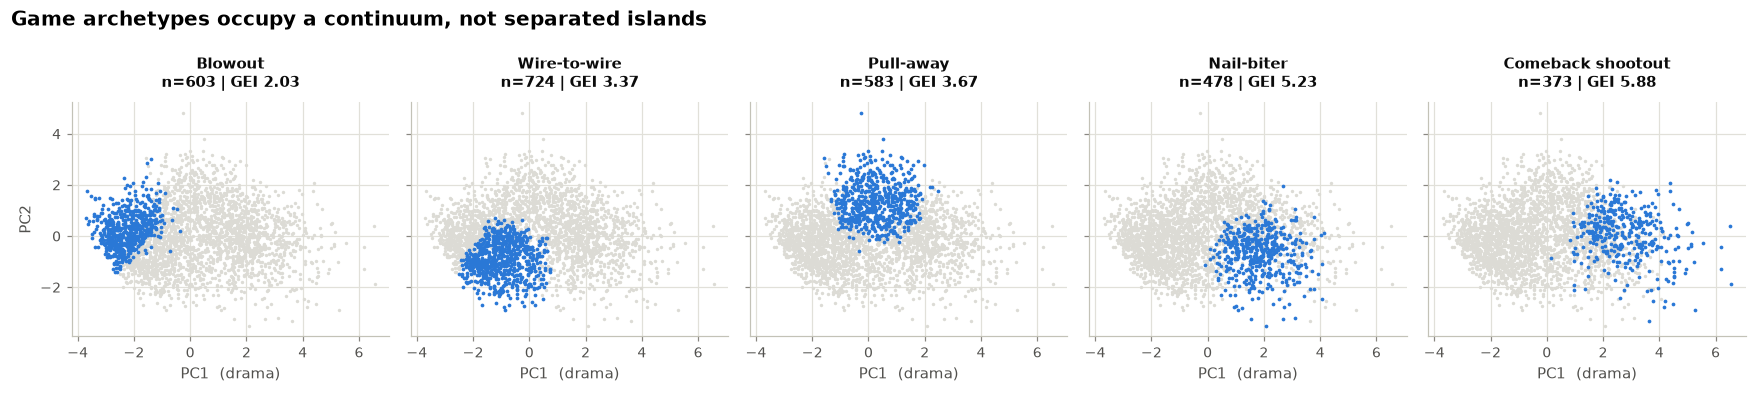

In [51]:
# show each cluster plotted by the principle components
fig, axes = plt.subplots(1, K, figsize=(16, 3.6), sharex=True, sharey=True)
for ax_, c in zip(axes, ORDER):
    mask = games.cluster == c
    ax_.scatter(coords[~mask.values, 0], coords[~mask.values, 1], s=5,
                color="#dcdbd5", linewidths=0)
    ax_.scatter(coords[mask.values, 0], coords[mask.values, 1], s=6,
                color=BLUE, linewidths=0)
    ax_.set_title(f"{NAMES[c]}\nn={mask.sum()} | GEI {games.loc[mask,'gei'].mean():.2f}",
                  fontsize=10, loc="center")
    ax_.set_xlabel("PC1  (drama)")
    tidy(ax_, "both")
axes[0].set_ylabel("PC2")
fig.suptitle("Game archetypes occupy a continuum, not separated islands",
             x=0.005, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Figure 10.** Each plot highlights one archetype in the same PCA projection.

PC1 captures 44.7% of the variance and is positively tied to every drama feature (`q4_volatility` 0.45, `winner_trailed_frac` 0.41, `peak_swing` 0.40, `lead_changes` 0.39) and
negatively on `final_margin` (−0.38). **PC1 is roughly GEI rediscovered from scratch**: an unsupervised method, given only shape features, recovers the same information constructed by hand, providing independent support meaningful to the original metric.

PC2 (16.3%) separates on `wp_std` and `total_points`: it distinguishes high-scoring games with swings from low-scoring grinds. The address the note from earlier that the naive methods failed to learn.

The plots show visually why the silhouette was low: the archetypes form a single cloud rather than distinct islands.

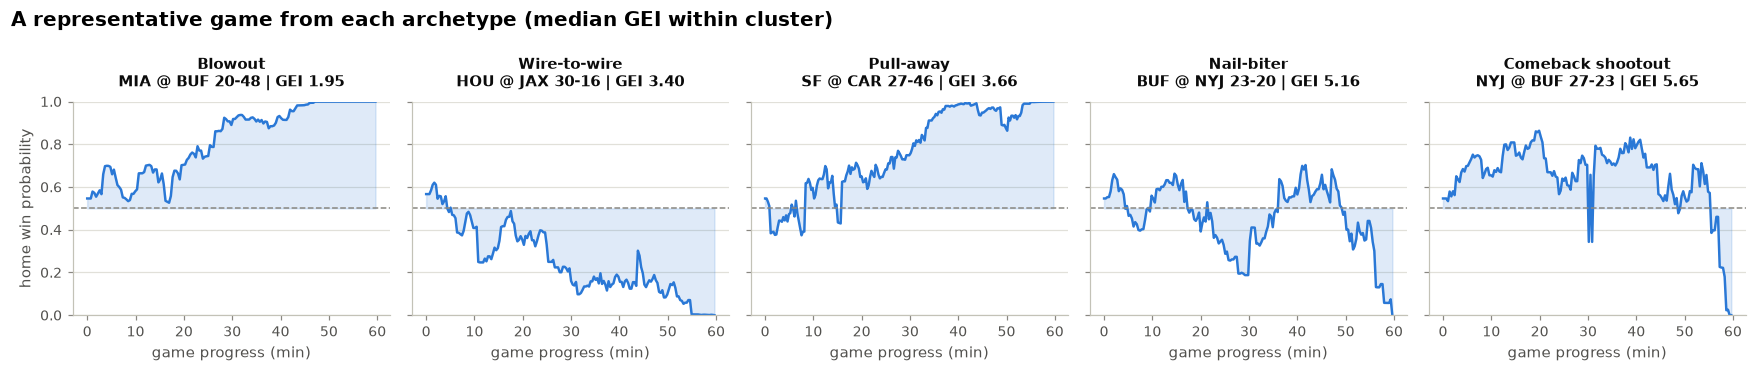

Share of each GEI quartile by archetype:
archetype      Blowout  Comeback shootout  Nail-biter  Pull-away  Wire-to-wire
gei                                                                           
Q1 (boring)       72.2                0.0         0.0        6.8          21.0
Q2                14.1                1.2         0.6       37.5          46.7
Q3                 1.0               11.4        19.9       34.9          32.8
Q4 (exciting)      0.0               41.4        48.8        5.2           4.5


In [54]:
fig, axes = plt.subplots(1, K, figsize=(16, 3.4), sharey=True)
for ax_, c in zip(axes, ORDER):
    sub = games[games.cluster == c]
    rep = sub.iloc[(sub.gei - sub.gei.median()).abs().argsort().iloc[0]]
    p = pbp[pbp.game_id == rep.game_id]
    elapsed = np.arange(len(p)) / len(p) * 60
    ax_.plot(elapsed, p["home_wp"], color=BLUE, linewidth=1.6)
    ax_.fill_between(elapsed, p["home_wp"], 0.5, color=BLUE, alpha=0.15)
    ax_.axhline(0.5, color=INK_MUTED, linewidth=1, linestyle="--")
    ax_.set_ylim(0, 1)
    ax_.set_xlabel("game progress (min)")
    ax_.set_title(f"{NAMES[c]}\n{rep.matchup} {rep.away_score:.0f}-{rep.home_score:.0f}"
                  f" | GEI {rep.gei:.2f}", fontsize=9.5, loc="center")
    tidy(ax_, "y")
axes[0].set_ylabel("home win probability")
fig.suptitle("A representative game from each archetype (median GEI within cluster)",
             x=0.005, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

xt = pd.crosstab(pd.qcut(games.gei, 4, labels=["Q1 (boring)", "Q2", "Q3", "Q4 (exciting)"]),
                 games.archetype, normalize="index")
print("Share of each GEI quartile by archetype:")
print((xt * 100).round(1).to_string())

**Figure 11.** The median game drawn from each archetype shown as a win-probability over time.

The five shapes are visually distinct even though the clusters are not statistically separated:

| Archetype | n | Mean GEI | Signature |
|---|---|---|---|
| **Blowout** | 603 | 2.03 | Winner never trailed; 23.9-point average margin; the line is on one side by halftime |
| **Wire-to-wire** | 724 | 3.37 | Winner led essentially throughout, but by a manageable 8.3 points |
| **Pull-away** | 583 | 3.67 | Winner trailed 37% of the game before taking over; the highest-scoring of the dull games |
| **Nail-biter** | 478 | 5.23 | 4.3-point margin, low-scoring (39 points), 43% of the game inside a 40–60% win probability |
| **Comeback shootout** | 373 | 5.88 | Winner trailed 59% of the game, 55.9 points, the largest single swings |

The cross-tabulation confirms the archetypes track excitement well without being defined by it. The most boring GEI quartile is 72% Blowouts and contains zero Nail-biters or Comeback shootouts, while the exciting quartile is 90% those two. The useful distinction is between the two exciting archetypes. **Nail-biters** are low-scoring and close defensive games decided late. **Comeback shootouts** are high-scoring games where the winner spent most of the matchup losing. Both rate as excellent, for opposite reasons, and a broadcast marketing "a defensive struggle" and "a shootout" is selling different products. A single GEI number cannot make that distinction, but this decomposition can.

## 7. Results and Evaluation

A summary table is provided, showing every model scored only on data it never trained on vs the baseline it had to beat.

In [59]:
results = pd.DataFrame([
    {"§": "5.2", "Task": "Predict game winner (team-game)", "Model": "Logistic regression",
     "Metric": "ROC-AUC", "Baseline": 0.500, "Score": win_auc, "Protocol": f"train <=2024 -> test {TEST_SEASON}"},
    {"§": "5.2", "Task": "Predict game winner (team-game)", "Model": "Logistic regression",
     "Metric": "Accuracy", "Baseline": 0.500, "Score": win_acc, "Protocol": f"train <=2024 -> test {TEST_SEASON}"},
    {"§": "5.2", "Task": "Predict game winner (team-game)", "Model": "Logistic regression",
     "Metric": "Brier ↓", "Baseline": 0.250, "Score": win_brier, "Protocol": f"train <=2024 -> test {TEST_SEASON}"},
    {"§": "6.1", "Task": "Predict GEI pre-game", "Model": "RidgeCV",
     "Metric": "R^2", "Baseline": 0.000, "Score": wf.ridge_r2.mean(), "Protocol": "walking, 6 seasons"},
    # Baseline is the mean of the per-fold baselines, so it is measured on the same six test seasons as the score beside it.
    {"§": "6.1", "Task": "Predict GEI pre-game", "Model": "RidgeCV",
     "Metric": "MAE ↓", "Baseline": wf.base_mae.mean(), "Score": wf.ridge_mae.mean(), "Protocol": "walking, 6 seasons"},
    {"§": "6.1", "Task": "Predict GEI pre-game", "Model": "HistGradientBoosting",
     "Metric": "R^2", "Baseline": 0.000, "Score": wf.hgb_r2.mean() if "hgb_r2" in wf else np.nan,
     "Protocol": "walking, 6 seasons"},
    {"§": "6.1", "Task": "Classify thriller pre-game", "Model": "Logistic (13 features)",
     "Metric": "ROC-AUC", "Baseline": 0.500, "Score": wf.logit_auc.mean(), "Protocol": "walking, 6 seasons"},
    {"§": "6.1", "Task": "Classify thriller pre-game", "Model": "HistGradientBoosting",
     "Metric": "ROC-AUC", "Baseline": 0.500, "Score": wf.hgb_auc.mean(), "Protocol": "walking, 6 seasons"},
    {"§": "6.1", "Task": "Classify thriller pre-game", "Model": "Logistic (spread only)",
     "Metric": "ROC-AUC", "Baseline": 0.500, "Score": wf.spread_auc.mean(), "Protocol": "walking, 6 seasons"},
])
results["Delta vs baseline"] = np.where(results.Metric.str.contains("↓"),
                                    results.Baseline - results.Score,
                                    results.Score - results.Baseline)
results["Verdict"] = np.where(results["Delta vs baseline"] > 0.05, "beats baseline",
                     np.where(results["Delta vs baseline"] > 0.01, "marginal", "no better than baseline"))
print(results.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

  §                            Task                  Model   Metric  Baseline  Score                  Protocol  Delta vs baseline                 Verdict
5.2 Predict game winner (team-game)    Logistic regression  ROC-AUC     0.500  0.811 train <=2024 -> test 2025              0.311          beats baseline
5.2 Predict game winner (team-game)    Logistic regression Accuracy     0.500  0.724 train <=2024 -> test 2025              0.224          beats baseline
5.2 Predict game winner (team-game)    Logistic regression  Brier ↓     0.250  0.178 train <=2024 -> test 2025              0.072          beats baseline
6.1            Predict GEI pre-game                RidgeCV      R^2     0.000  0.011        walking, 6 seasons              0.011                marginal
6.1            Predict GEI pre-game                RidgeCV    MAE ↓     1.245  1.233        walking, 6 seasons              0.012                marginal
6.1            Predict GEI pre-game   HistGradientBoosting      R^2     0.00

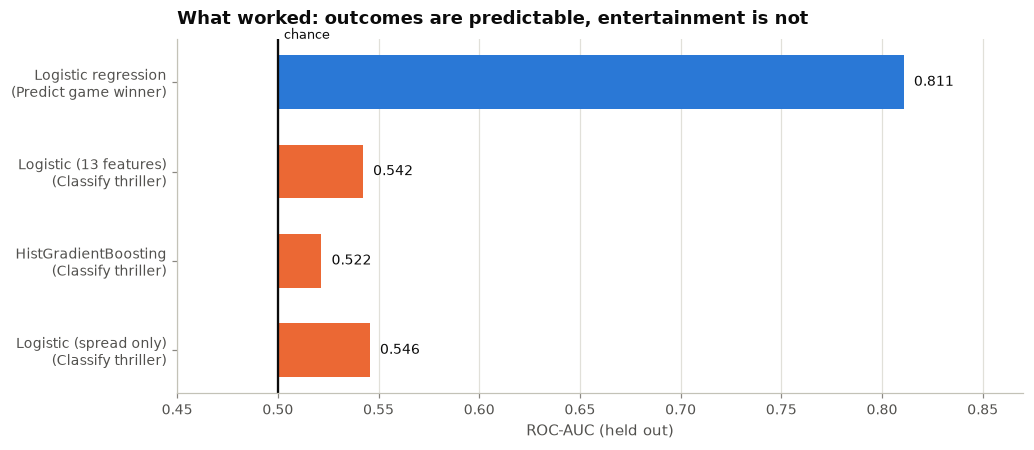

In [29]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
auc_rows = results[results.Metric == "ROC-AUC"].copy()
labels = [f"{r.Model}\n({r.Task.split(' pre-game')[0].split('(')[0].strip()})"
          for _, r in auc_rows.iterrows()]
y = np.arange(len(auc_rows))
ax.barh(y, auc_rows.Score - 0.5, left=0.5,
        color=[BLUE if v > 0.55 else ORANGE for v in auc_rows.Score], height=0.6)
ax.axvline(0.5, color=INK, linewidth=1.5)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlim(0.45, 0.87)
ax.set_xlabel("ROC-AUC (held out)")
for i, v in enumerate(auc_rows.Score):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9, color=INK)
ax.invert_yaxis()
# After the flip, -0.45 is just above the topmost bar -- clear of the x tick labels.
ax.text(0.503, -0.45, "chance", fontsize=8.5, color=INK, va="bottom")
ax.set_title("What worked: outcomes are predictable, entertainment is not")
tidy(ax, "x")
plt.tight_layout()
plt.show()

**Figure 12.** All classification results on one axis, measured from chance.

**What held up.** The win model is a clear success: AUC 0.811, 72.4% accuracy, and a Brier score
29% better than uninformed — from six aggregate box-score-adjacent numbers, on a season it never
saw. Retrospective explanation of football outcomes works.

**What did not.** Every pre-game excitement model sits within 0.05 AUC of chance, and the
regression models explain about 1% of variance. Adding twelve features to the point spread
bought nothing. Gradient boosting did not beat linear models, which is itself diagnostic: when a
flexible model cannot outperform a linear one, the usual reason is that there is no structure
left to find.

**On the evaluation protocol.** The headline split and the walk-forward disagreed about §6.1 —
2025 alone said AUC 0.48 (worse than chance), six seasons said 0.542 (slightly better). Neither
is large, but the sign flipped. Any single-season conclusion here would have been an artefact of
which season we happened to hold out.

## 8. Insights and Conclusions

### 8.1 Answers to the Phase 1 questions

**1. Can we grade the entertainment value of every game?** Yes. GEI produces a defensible
per-game score, validated in §5.1 against five independent measures (ρ = 0.66–0.90) and
independently recovered as the dominant principal component of game shape in §6.2. It carries
one documented bias — overtime games score roughly double, taking every one of the top 50 slots
from 5.6% of games — which we report rather than correct away, since total drama really is what a
viewer consumes. Conclusions that depend on it were re-checked against regulation-only GEI.

**2. What advanced metrics correlate with winning?** EPA per play, decisively: +1.49 log-odds
per standard deviation, four times the next feature. Turnovers are the main negative (−0.37) and
home field a real but small positive (+0.31). The more important methodological finding is that
Phase 1's one-at-a-time correlations were misleading — success rate and explosive-play rate look
positive marginally and turn negative once EPA is in the model, because EPA already contains
them.

**3. How do location and rest affect outcomes?** Both are minor. Home field is worth a modest
edge in the win model. Rest differential contributes nothing measurable to either winning or
excitement — it is among the deadest features in §6.1. Phase 1 noticed that extra rest did not
help in 2019 and wondered whether that was a fluke; across ten seasons, it holds.

**4. Can we build momentum charts?** Yes (§4.3), and we generalised them: §6.2 turns the shape
of the win-probability path into eight features and recovers five interpretable game archetypes,
from Blowouts (GEI 2.03) to Comeback shootouts (GEI 5.88).

### 8.2 The central finding

**NFL game excitement is essentially unpredictable before kickoff.** Across six held-out seasons,
thirteen pre-game features reach AUC 0.542 — and the closing point spread alone does just as well
at 0.546. Everything else the schedule knows about a game is worthless for this purpose.

This is a null result, and we think it is the most valuable thing here, for three reasons:

1. **It is well-tested.** Two model families, two target definitions, two evaluation protocols,
   and a robustness check against a different GEI variant all agree.
2. **It has a mechanism.** The betting market is the most efficient aggregator of pre-game NFL
   information in existence. It prices *who will win* accurately. Its near-total failure to
   price *whether the game will be good* means the information does not exist at kickoff, rather
   than that we failed to find it.
3. **It is actionable.** Flex scheduling is premised on identifying good games in advance. Our
   §4.4 result — primetime games are no more exciting than average — is the same finding observed
   from the league's own decisions. The lever that does work is matchup closeness, which is a
   competitive-balance question, not a scheduling one.

The complement is equally clean: what happens *during* a game is highly legible (AUC 0.811),
what will happen *before* it is not. NFL parity is strong enough that the drama is generated on
the field, not by the matchup.

### 8.3 Limitations

- **GEI inherits a model.** Win probability is itself estimated; systematic errors in it become
  systematic errors in GEI. We mitigate by cross-checking against measures that do not use WP
  (final margin, lead changes, total points), but we cannot fully escape it.
- **Excitement is operationalised, not measured.** We never observed a human calling a game
  exciting. Validating GEI against ratings data, second-screen engagement, or a fan survey is
  the obvious next step and would turn convergent validity into criterion validity.
- **No injury data.** A quarterback leaving in the first quarter reshapes a game, and none of
  our features can see it. This is plausibly a real part of the unexplained 99%.
- **Ten seasons is 2,761 games.** Adequate for the effects we found; underpowered for small
  interactions (e.g. whether cold-weather division games behave differently).
- **The clusters are a discretisation.** Silhouette 0.19 at k = 5 says the boundaries are
  analyst-imposed. The archetype *labels* are ours; the continuum is the data's.
- **Regular-season structure changed mid-window.** The league moved from 16 to 17 games in 2021.
  Section 4.1 found no GEI trend across the change, so we pooled, but the window is not perfectly
  homogeneous.

### 8.4 Future work

The highest-value next step is not a better model — it is a better target. Every §6.1 result is
bounded by whether GEI is what people mean by "good game", and that is an empirical question we
did not test. Pairing GEI with viewership retention data would answer it.

Failing that, the natural extension is **in-game** forecasting: excitement is unpredictable at
kickoff, but by halftime a great deal is knowable. A model that estimates "will the second half
be worth staying for" has an obvious use in a world of live streaming, and unlike the pre-game
problem, it has information to work with.

## 9. References

**Data**

1. **nflverse.** *nflverse-data: play-by-play and schedule releases.* https://github.com/nflverse/nflverse-data — primary data source (2016–2025), accessed via `nflreadpy` v0.1.5.
2. **nflreadpy.** *Python package for nflverse data.* https://nflreadpy.nflverse.com/
3. **Yurko, R., Ventura, S., & Horowitz, M. (2019).** nflWAR: A Reproducible Method for Offensive Player Evaluation in Football. *Journal of Quantitative Analysis in Sports*, 15(3), 163–183. — the nflscrapR expected-points and win-probability framework that nflverse continues.
4. **Ryurko, R.** *nflscrapR-data.* https://github.com/ryurko/nflscrapR-data — the Phase 1 data source, retained for comparison.

**Methods**

5. **Burke, B. (2008).** *Game Excitement Index.* Advanced Football Analytics. http://www.advancedfootballanalytics.com/ — the Σ|WPA| formulation used here.
6. **Lock, D., & Nettleton, D. (2014).** Using random forests to estimate win probability before each play of an NFL game. *Journal of Quantitative Analysis in Sports*, 10(2), 197–205.
7. **Pedregosa, F., et al. (2011).** Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830. — logistic regression, RidgeCV, HistGradientBoosting, PCA, KMeans.
8. **Rousseeuw, P. J. (1987).** Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53–65.

**Tooling and visual design**

9. **Harris, C. R., et al. (2020).** Array programming with NumPy. *Nature*, 585, 357–362.
10. **The pandas development team (2026).** *pandas-dev/pandas.*
11. **Hunter, J. D. (2007).** Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95.
12. **Series Graph.** https://seriesgraph.com/ — the IMDb episode-rating grid that inspired the season heat map in §4.2.

## 10. Appendix

### 10.1 Reproducing this notebook

```bash
git clone <repo> && cd dsci521-nfl-excitement-grid
python3 -m venv .venv && .venv/bin/pip install -r requirements.txt
.venv/bin/python -m ipykernel install --user --name dsci521-nfl
.venv/bin/jupyter lab DSCI_521_Group3_Final.ipynb     # select the dsci521-nfl kernel
```

Run all cells. The first run downloads and caches ten seasons of nflverse data into `data/cache/`
(~64 MB); later runs read the cache. Verified end to end from an empty cache in **27 seconds**.
`data/` is git-ignored, so a fresh clone rebuilds it automatically. Every model is seeded
(`RANDOM_STATE = 0`) and results are deterministic.

**Repository layout**

| Path | Contents |
|---|---|
| `DSCI_521_Group3_Final.ipynb` | This report |
| `DSCI_521_Group3.ipynb` | Phase 1 scoping submission (runs locally; no longer Colab-only) |
| `src/data.py` | Cached nflverse loaders and the column allow-lists |
| `src/plots.py` | `show_wp_graph`, `show_excitement_chart` — the carried-over Phase 1 figures |
| `src/main.py` | Standalone script entry point |
| `requirements.txt` | Pinned environment |

### 10.2 Data dictionary — columns used in this analysis

| Column | Source table | Meaning |
|---|---|---|
| `wpa` | play-by-play | Change in home win probability caused by this play. Sums to GEI. |
| `home_wp` / `away_wp` | play-by-play | Win probability before the play |
| `epa` | play-by-play | Expected points added by the play |
| `success` | play-by-play | 1 if the play produced positive EPA |
| `qtr`, `quarter_seconds_remaining` | play-by-play | The correct sort key (see §3.4) |
| `game_seconds_remaining` | play-by-play | Countdown; **restarts at 600 in overtime** |
| `total_home_score` / `total_away_score` | play-by-play | Score before the play; source of lead changes |
| `play_type`, `yards_gained`, `interception`, `fumble_lost`, `third_down_converted` | play-by-play | Inputs to the §5.2 team-game features |
| `spread_line`, `total_line` | schedules | Closing betting market lines |
| `home_rest`, `away_rest` | schedules | Days since each team's previous game |
| `div_game`, `roof`, `surface`, `temp`, `wind` | schedules | Matchup and venue context |
| `gameday`, `weekday`, `gametime` | schedules | Kickoff timing; source of the primetime flag |
| `result` | schedules | Home score − away score; `abs()` is final margin |

### 10.3 Derived measures

| Measure | Defined in | Definition |
|---|---|---|
| `gei` | §4.1 | Σ&#124;WPA&#124; over all plays |
| `gei_reg` | §5.1 | Σ&#124;WPA&#124; over regulation only (quarters 1–4) |
| `comeback` | §4.1 | max(0, 0.5 − minimum win probability of the eventual winner) |
| `lead_changes` | §4.1 | Sign changes in (home score − away score), zeros removed |
| `late_tension` | §4.1 | 0.5 − mean&#124;WP − 0.5&#124; over the final 5 minutes |
| `off_form` / `def_form` | §6.1 | Expanding mean of EPA/play over strictly prior games this season |
| `archetype` | §6.2 | KMeans (k=5) label over eight standardised WP-curve shape features |

### 10.4 Division of responsibilities

| Area | Deliverable |
|---|---|
| Data preparation | Cached nflverse loaders, column selection, coverage and missingness audits, the §3.4 ordering fix |
| Analysis and modelling | GEI validation, win model, pre-game prediction, walk-forward protocol, clustering |
| Visualization | Figures 1–12, house palette, the sequential-ramp replacement for the Phase 1 rainbow |
| Documentation | This notebook's narrative, data dictionary, README, reproducibility instructions |
| Presentation | Slides summarising motivation, method, the negative result, and limitations |